# A. Importation of libraries and Configs

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
from types import SimpleNamespace

args = SimpleNamespace(
    # Path to the pseudonymized revenues dataset
    dataset_dir     = r"Database\revenues_pseudonymized.xlsx",
    # Path to the enrollee infos
    enrollees_dir   = r"Database\enrollees_pseudonymized.xlsx",
    # Path to the machine learning model parameters
    parameters_dir  = r"machine_learning\parameters.json",

    # Path to cache directory to store preprocessed dataset if needed
    cache_dir       = "",
    load_cache      = True,

    # Path to store results (relative to project root — works on any machine)
    results_dir     = r"Results",

    # The date used
    observation_end = datetime.today(),

    # Class to predict
    target_feature  = 'dtp_bracket',
    # Test size in %
    test_size       = 0.3,

    # Time points used in generating survival features
    time_points     = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450],
)


# B. Loading of datasets

## 1. Revenues

In [3]:
df_revenues = pd.read_excel(args.dataset_dir)

In [4]:
df_revenues

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables
0,0,2025-10-13,2025-10-13,2014,9XBPS6GQ,Form 137,NaN,150.0,150.0,G-Cash,0.0
1,1,2016-01-01,2016-01-01,2016,QCNXOF71,Back Account,NaN,3524.0,0.0,Not Applicable,3524.0
2,2,2016-01-01,2016-01-01,2016,UFN5RBCA,Back Account,NaN,9831.0,0.0,Not Applicable,9831.0
3,3,2016-01-01,2016-01-01,2016,CATF26JR,Back Account,NaN,9240.0,0.0,Not Applicable,9240.0
4,4,2016-01-01,2016-01-01,2016,TE11Z2LJ,Back Account,NaN,5886.0,0.0,Not Applicable,5886.0
...,...,...,...,...,...,...,...,...,...,...,...
52922,54081,2026-03-30,2026-12-04,2026,EC3NOT2L,G02-OF-2nd,NaN,5467.0,0.0,Not Applicable,5467.0
52923,54082,2026-03-30,2027-03-05,2026,EC3NOT2L,G02-OF-3rd,NaN,5466.0,0.0,Not Applicable,5466.0
52924,54083,2026-03-31,2026-03-31,2026,DVWWAMWI,Uniform - Students - Daily,NaN,4390.0,4390.0,Bank,0.0
52925,54084,2026-03-31,2026-03-31,2026,ES2CJRD6,Reservation Fee - SpEd,NaN,3000.0,3000.0,Bank,0.0


## 2. Enrollees

In [5]:
df_enrollees = pd.read_excel(args.enrollees_dir)

In [6]:
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2726,2026,YNT1UYY7,Plan - A,SpE,2026-01-31,Special Education,No Refund
2727,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund
2728,2026,ZDC3I53X,Plan - B,G10,2026-03-30,Junior High,No Refund
2729,2026,ZHRMZVJR,Plan - C,G06,2026-03-16,Elementary,No Refund


## 3. Credit Sales

In [7]:
from feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(df_revenues, df_enrollees, args)
df_credit_sales = cs.show_data()

Single due date records:   10377
Multiple due date records: 289


In [8]:
df_credit_sales.to_excel('credit_sale_invoices.xlsx', index=False)

In [9]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,days_elapsed_until_fully_paid,...,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,on_time_streak,prev_bracket,dtp_rolling_std,dtp_max,plan_type_risk_score
2206,2022,02PNVPI5,Kn2-C-1st,2800.0,0.0,0.0,2800.0,2022-09-09,2022-09-06,-3,...,9,3,0,1.034215,NaN,0,NaN,<NA>,<NA>,0
2448,2022,02PNVPI5,Kn2-C-2nd,2800.0,0.0,0.0,2800.0,2022-11-05,NaT,1260,...,11,4,1,0.943797,1.0,1,0.0,<NA>,-3,0
2850,2022,02PNVPI5,Kn2-OF-2nd,2267.0,0.0,0.0,2267.0,2022-12-05,NaT,1230,...,12,4,1,0.881408,NaN,0,NaN,<NA>,-3,0
2971,2022,02PNVPI5,Events - Foundation Day,490.0,0.0,0.0,490.0,2022-12-16,NaT,1219,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
2972,2022,02PNVPI5,Surcharge,336.0,0.0,0.0,336.0,2022-12-16,NaT,1219,...,12,4,1,0.805478,NaN,0,NaN,<NA>,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9796,2025,ZXPL0CI9,G06-C-4th,5800.0,0.0,0.0,5800.0,2026-02-06,2026-02-09,3,...,2,1,1,0.972245,0.0,0,2.0,10.456258,34,0
9881,2025,ZXPL0CI9,Graduation - Other Services,1500.0,0.0,0.0,1500.0,2026-02-18,2026-03-23,33,...,2,1,1,0.992873,0.0,0,1.0,14.614491,34,0
9960,2025,ZXPL0CI9,Events - Foundation,400.0,0.0,0.0,400.0,2026-03-05,2026-03-11,6,...,3,1,1,0.990990,0.0,0,2.0,15.340578,34,0
10297,2025,ZXPL0CI9,G06-OF-3rd,5800.0,0.0,0.0,5800.0,2026-03-06,2026-03-11,5,...,3,1,1,0.964462,0.0,0,1.0,16.792856,34,0


# C. Exploratory Data Analysis

In [10]:
# Get counts
counts = df_credit_sales.dtp_bracket.value_counts()

# Convert to percentages
percentages = counts / counts.sum() * 100

# Combine into one DataFrame
result = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})

print(result)

             count  percentage
dtp_bracket                   
on_time       3877       39.44
30_days       2996       30.48
90_days       1887       19.20
60_days       1070       10.89


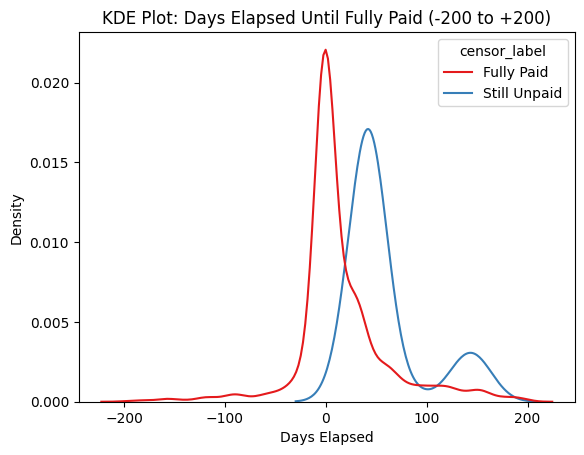

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Remove those that have no full dtp_history:
df_filtered = df_credit_sales.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])


# Clean and filter directly on the DataFrame
df_filtered = df_filtered.loc[
    df_filtered['days_elapsed_until_fully_paid']
        .replace("", np.nan)   # replace empty strings with NaN
        .dropna()              # drop NaNs
        .index                 # keep aligned index
]


# Apply numeric filter
df_filtered = df_filtered[
    (df_filtered['days_elapsed_until_fully_paid'] >= -200) &
    (df_filtered['days_elapsed_until_fully_paid'] <= 200)
]

# Convert censor column to categorical with labels
df_filtered["censor_label"] = (
    df_filtered["censor"]
    .map({0: "Still Unpaid", 1: "Fully Paid"})
    .astype("category")   # force categorical type
)


# KDE plot with grouping by categorical censor labels
sns.kdeplot(
    data=df_filtered,
    x="days_elapsed_until_fully_paid",
    hue="censor_label",
    fill=False,
    common_norm=False,
    palette="Set1"
)

plt.title("KDE Plot: Days Elapsed Until Fully Paid (-200 to +200)")
plt.xlabel("Days Elapsed")
plt.ylabel("Density")
plt.show()

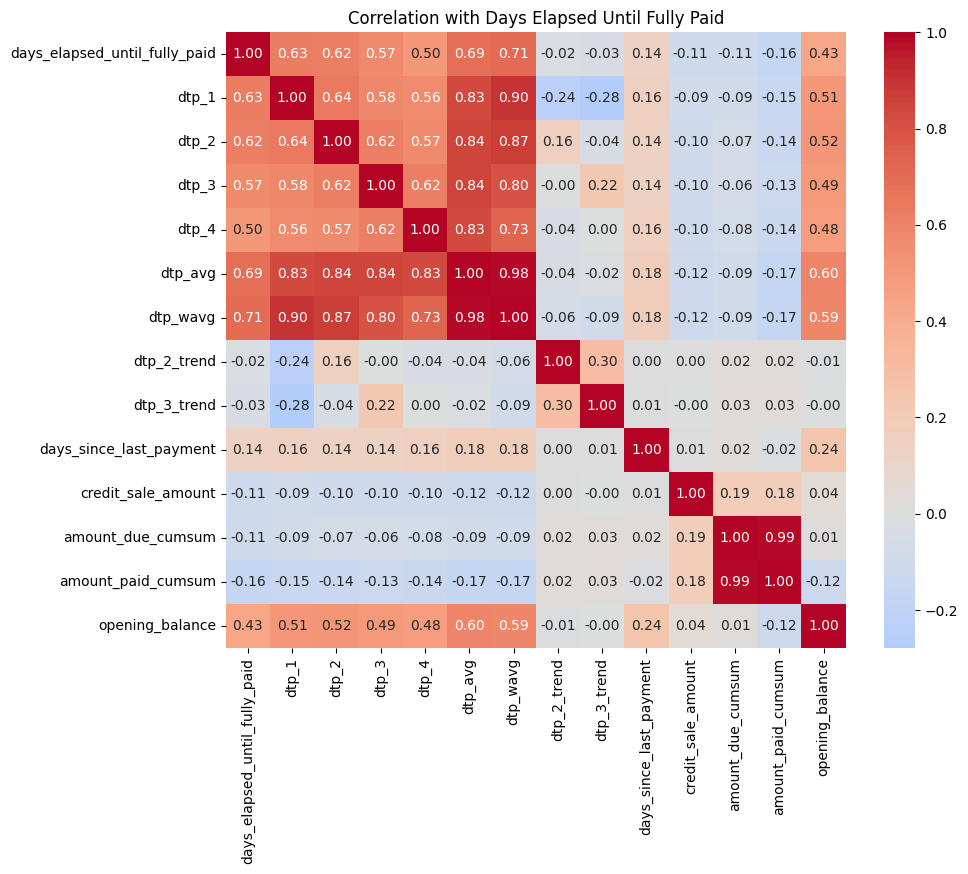

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid', 
        'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 
        'dtp_avg', 'dtp_wavg', 'dtp_2_trend',
        'dtp_3_trend', 'days_since_last_payment',
        'credit_sale_amount', 'amount_due_cumsum',
        'amount_paid_cumsum', 'opening_balance']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

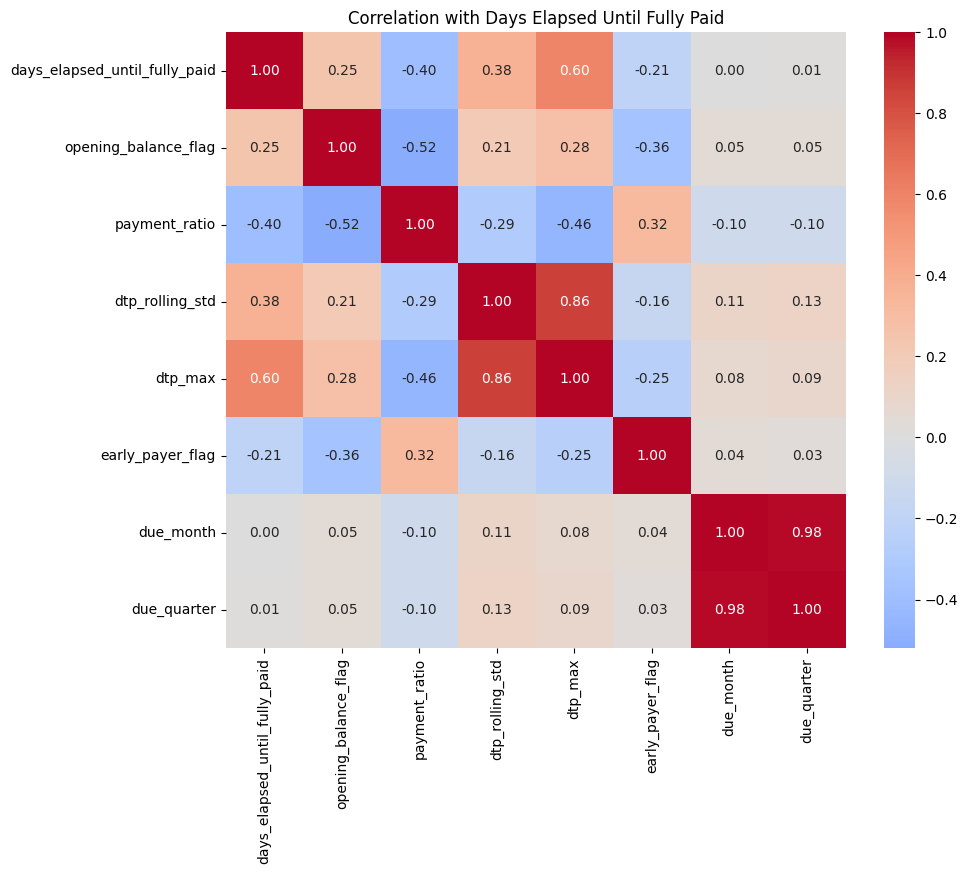

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid', 'opening_balance_flag', 'payment_ratio',
        'dtp_rolling_std', 'dtp_max', 'early_payer_flag',
        'due_month', 'due_quarter']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

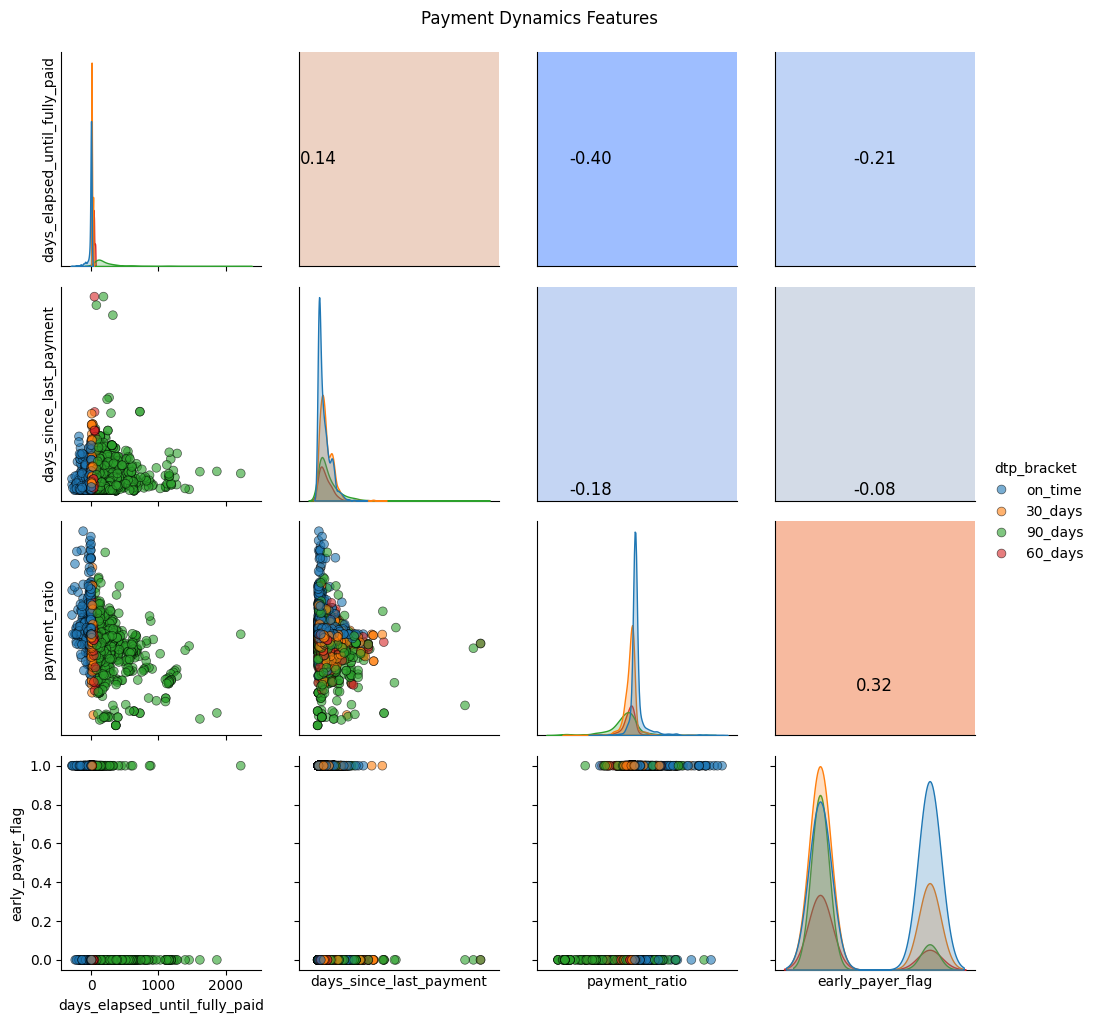

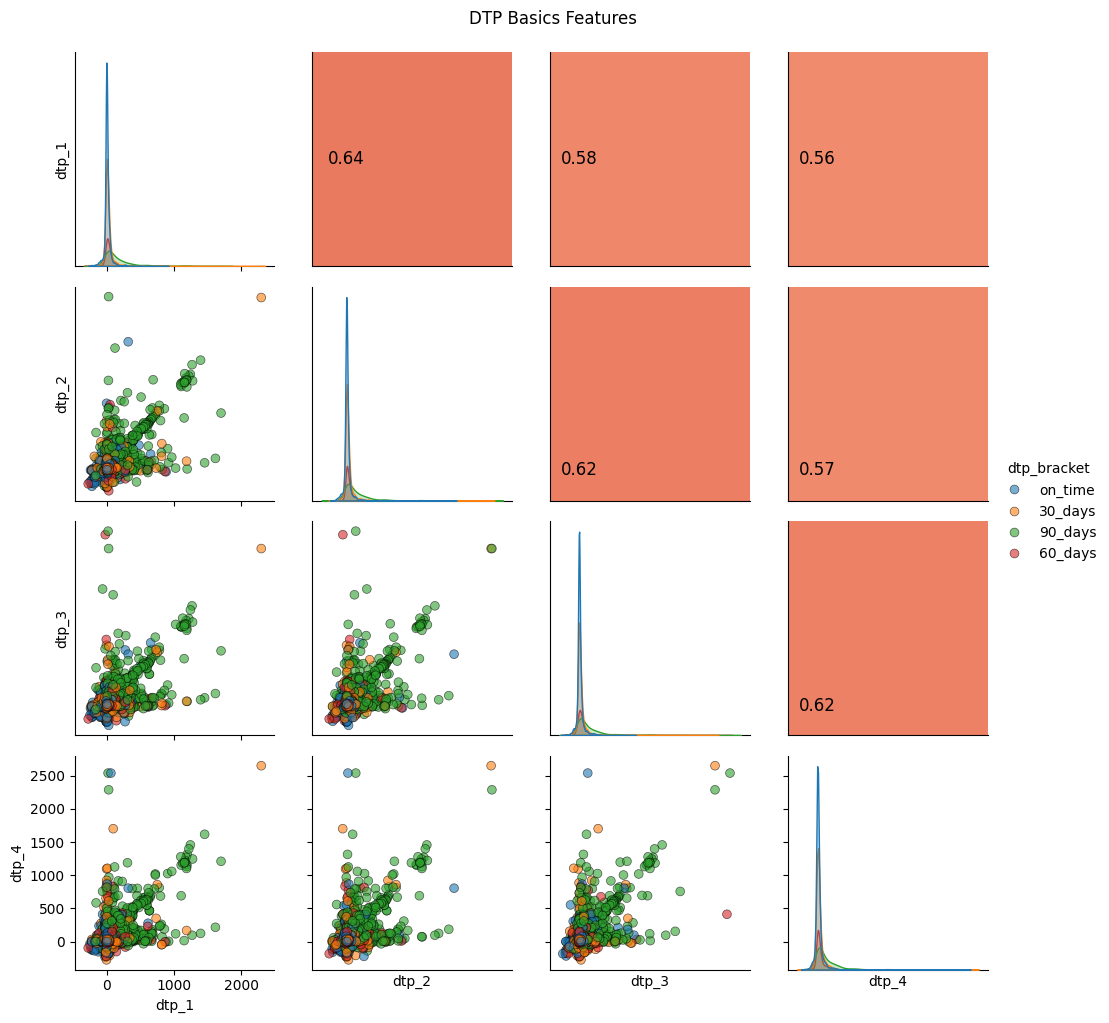

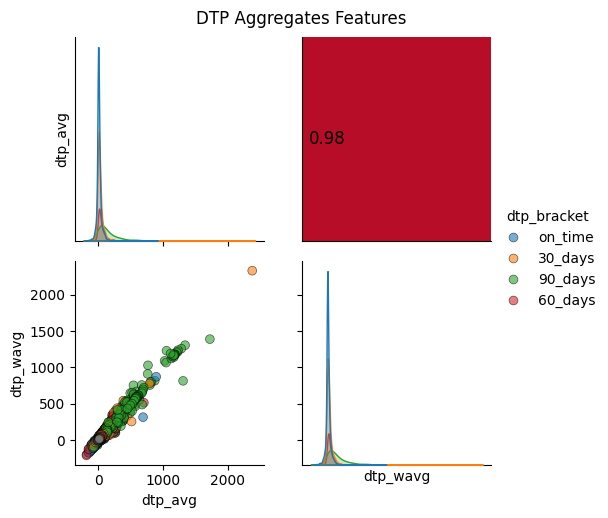

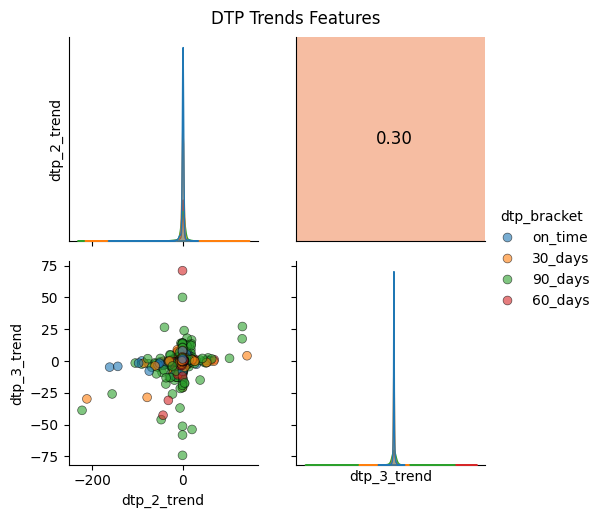

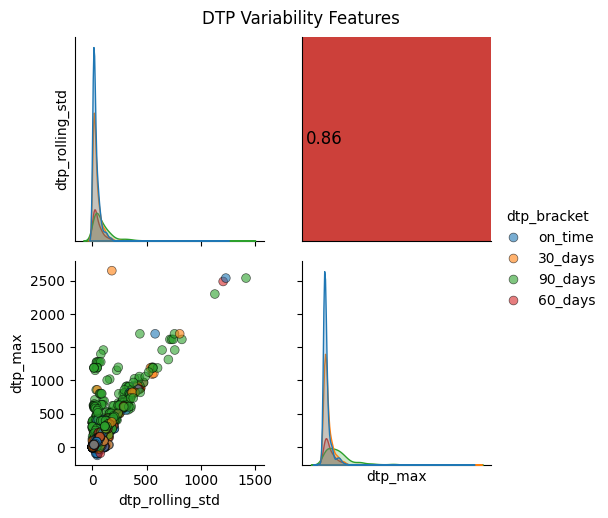

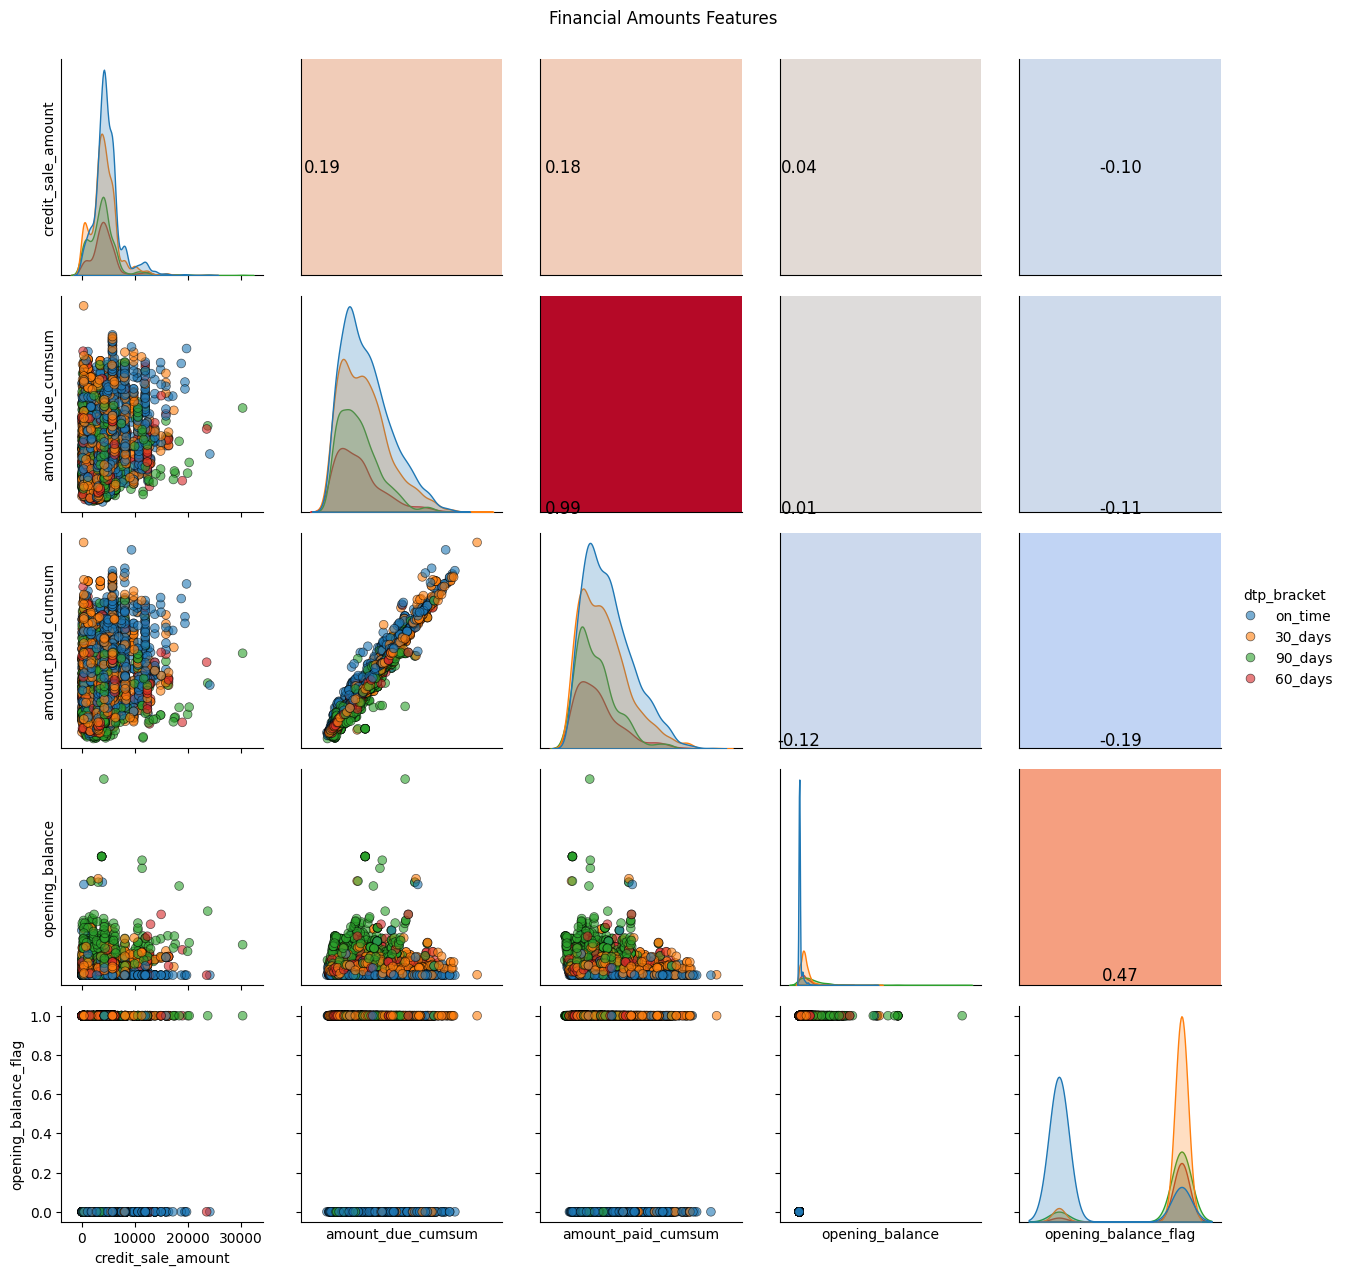

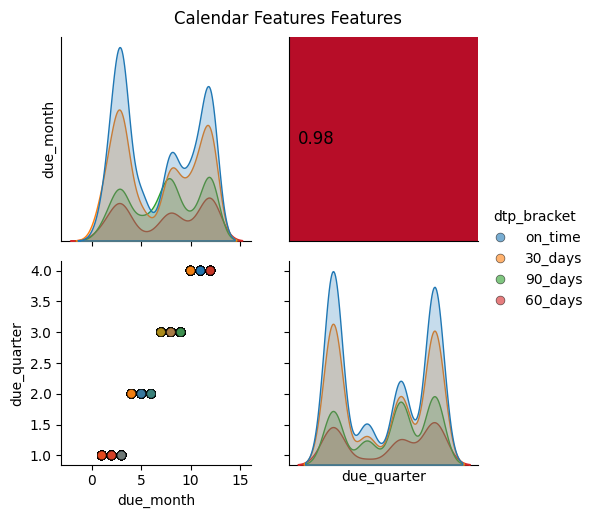

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter and clean data
df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Define groups of columns
groups = {
    "Payment Dynamics": [
        'days_elapsed_until_fully_paid', 'days_since_last_payment',
        'payment_ratio', 'early_payer_flag'
    ],
    "DTP Basics": ['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'],
    "DTP Aggregates": ['dtp_avg', 'dtp_wavg'],
    "DTP Trends": ['dtp_2_trend', 'dtp_3_trend'],
    "DTP Variability": ['dtp_rolling_std', 'dtp_max'],
    "Financial Amounts": [
        'credit_sale_amount', 'amount_due_cumsum',
        'amount_paid_cumsum', 'opening_balance',
        'opening_balance_flag'
    ],
    "Calendar Features": ['due_month', 'due_quarter']
}

def pairgrid_with_heatmap(df, cols, hue, title):
    # Build grid
    g = sns.PairGrid(df[cols + [hue]], hue=hue, diag_sharey=False)

    # Lower triangle: scatterplots
    g.map_lower(sns.scatterplot, alpha=0.6, s=40, edgecolor='k')

    # Diagonal: KDE plots
    g.map_diag(sns.kdeplot, fill=True)

    # Upper triangle: correlation heatmap
    corr = df[cols].corr()
    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if j > i:  # upper triangle only
                ax = g.axes[i, j]
                c = corr.loc[col_i, col_j]
                # Map correlation [-1,1] to colormap
                ax.set_facecolor(plt.colormaps['coolwarm']((c+1)/2))
                ax.text(0.5, 0.5, f"{c:.2f}", ha='center', va='center', fontsize=12)
                ax.set_xticks([])
                ax.set_yticks([])

    g.add_legend()
    plt.suptitle(title, y=1.02)
    plt.show()

# Generate plots for each group
for group_name, cols in groups.items():
    pairgrid_with_heatmap(df_filtered, cols, 'dtp_bracket', f"{group_name} Features")

### c. Linear Discriminant Analysis

In [15]:
df_credit_sales.columns

Index(['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments',
       'credit_sale_amount', 'due_date', 'date_fully_paid',
       'days_elapsed_until_fully_paid', 'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4',
       'dtp_avg', 'dtp_wavg', 'due_date_prev_1', 'due_date_prev_2',
       'dtp_2_trend', 'dtp_3_trend', 'last_payment_date',
       'days_since_last_payment', 'amount_due_cumsum', 'amount_paid_cumsum',
       'opening_balance', 'plan_type_Plan - A', 'plan_type_Plan - B',
       'plan_type_Plan - C', 'plan_type_Plan - D', 'plan_type_Plan - E',
       'plan_type_nan', 'dtp_bracket', 'censor', 'due_month', 'due_quarter',
       'opening_balance_flag', 'payment_ratio', 'early_payer_flag',
       'on_time_streak', 'prev_bracket', 'dtp_rolling_std', 'dtp_max',
       'plan_type_risk_score'],
      dtype='object')

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BRACKET_COL  = 'dtp_bracket'

DTP_FEATURES = [
    'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4',
    'dtp_avg', 'dtp_wavg',
    'dtp_rolling_std', 'dtp_max',
    'dtp_2_trend', 'dtp_3_trend'
]

FIN_FEATURES = [
    'credit_sale_amount', 'opening_balance',
    'amount_due_cumsum', 'amount_paid_cumsum'
]

BEHAVIOUR_FEATURES = [
    'payment_ratio', 'opening_balance_flag',
    'early_payer_flag', 'days_since_last_payment',
    'on_time_streak', 'prev_bracket'
]

TEMPORAL_FEATURES = ['due_month', 'due_quarter']

PLAN_FEATURES = [
    'plan_type_risk_score',
    'plan_type_Plan - A', 'plan_type_Plan - B',
    'plan_type_Plan - C', 'plan_type_Plan - D',
    'plan_type_Plan - E', 'plan_type_nan'
]

ALL_FEATURES = (
    DTP_FEATURES +
    FIN_FEATURES +
    BEHAVIOUR_FEATURES +
    TEMPORAL_FEATURES +
    PLAN_FEATURES
)

BRACKET_ORDER  = ['on_time', '30_days', '60_days', '90_days']
BRACKET_COLORS = {
    'on_time': "#382ecc",
    '30_days': "#68e25d",
    '60_days': "#7ab7f0",
    '90_days': '#e07b72',
}


# ─────────────────────────────────────────────
# DATA HELPERS
# ─────────────────────────────────────────────

def load_and_prepare(df):
    """Clean and split into X (float64) and y (bracket label)."""
    cols_needed = ALL_FEATURES + [BRACKET_COL]
    df_clean = df[cols_needed].dropna()
    df_clean = df_clean[df_clean[BRACKET_COL].isin(BRACKET_ORDER)]
    X = df_clean[ALL_FEATURES].astype(float).copy()
    y = df_clean[BRACKET_COL].copy()
    return X, y


def log1p_transform(X):
    """log1p-transform financial features; leave DTP features untouched."""
    X_t = X.astype(float).copy()
    for col in FIN_FEATURES:
        if col in X_t.columns:
            shift = abs(X_t[col].min()) if X_t[col].min() < 0 else 0
            X_t[col] = np.log1p(X_t[col] + shift)
    return X_t


def fit_lda(X, y):
    """Scale then fit LDA; return (pipeline, projected array, explained var ratio)."""
    n_components = min(len(BRACKET_ORDER) - 1, X.shape[1])   # max 3
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lda',    LinearDiscriminantAnalysis(n_components=n_components,
                                              solver='svd')),
    ])
    X_lda = pipe.fit_transform(X, y)
    evr   = pipe.named_steps['lda'].explained_variance_ratio_
    return pipe, X_lda, evr


def compute_class_separation(X, y):
    """Fisher between/within variance ratio per feature."""
    rows = []
    for col in X.columns:
        overall_mean = X[col].mean()
        classes      = y.unique()
        between = sum(
            (y == c).sum() * (X.loc[y == c, col].mean() - overall_mean) ** 2
            for c in classes
        ) / len(y)
        within = sum(
            X.loc[y == c, col].var() * (y == c).sum()
            for c in classes
        ) / len(y)
        rows.append({'feature': col,
                     'separation': between / within if within > 0 else 0})
    return pd.DataFrame(rows).sort_values('separation', ascending=False)


# ─────────────────────────────────────────────
# ATOMIC PLOT HELPERS
# ─────────────────────────────────────────────

def _draw_raw_hist(ax, col, y, feat, show_legend=False):
    """Overlapping density histogram for one raw feature."""
    col = col.astype(float)
    lo, hi = col.quantile(0.01), col.quantile(0.99)
    for bracket in BRACKET_ORDER:
        vals = col[y == bracket].clip(lo, hi)
        ax.hist(vals, bins=60, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_hist(ax, X_lda, y, evr, ld_idx, show_legend=False):
    """Density histogram for one LDA discriminant axis."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.hist(X_lda[mask, ld_idx], bins=80, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(f'LD{ld_idx+1}  ({evr[ld_idx]*100:.1f}% sep. var.)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'LD{ld_idx+1} score', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_scatter(ax, X_lda, y, evr):
    """LD1 vs LD2 2-D scatter coloured by bracket."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
                   s=5, alpha=0.28, color=BRACKET_COLORS[bracket],
                   label=bracket, rasterized=True)
    ax.set_xlabel(f'LD1  ({evr[0]*100:.1f}%)', fontsize=8)
    ld2_label = f'LD2  ({evr[1]*100:.1f}%)' if len(evr) > 1 else 'LD2'
    ax.set_ylabel(ld2_label, fontsize=8)
    ax.set_title('LD1 vs LD2 — 2-D projection', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, markerscale=3)
    ax.tick_params(labelsize=7)


def _col_header(ax, text, color):
    """Solid-background header label above an axis."""
    ax.annotate(text, xy=(0.5, 1.24), xycoords='axes fraction',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.4', fc=color,
                          alpha=0.85, ec='none'))


def _draw_separation_bar(ax, sep_before, sep_after):
    """Grouped bar chart: Fisher separation before vs after."""
    features = sep_before['feature'].tolist()
    x, w     = np.arange(len(features)), 0.35
    b_vals   = sep_before.set_index('feature').loc[features, 'separation'].values
    a_vals   = sep_after.set_index('feature').loc[features,  'separation'].values
    ax.bar(x - w/2, b_vals, w, label='Before (raw)',         color='#aab7b8')
    ax.bar(x + w/2, a_vals, w, label='After (log1p+scaled)', color='#5dade2')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel("Fisher's separation ratio", fontsize=9)
    ax.set_title("Per-feature class separation — before vs after log1p transform",
                 fontsize=10)
    ax.legend(fontsize=8)


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run_lda_analysis(df):
    """
    Two-column layout — one feature per row:

        LEFT  column  =  BEFORE  (raw histogram, p1–p99 clipped)
        RIGHT column  =  AFTER   (LDA component histogram)

    Feature rows:
        Rows 0–5   : dtp_1, dtp_2, dtp_3, dtp_4, dtp_avg, dtp_wavg
        Rows 6–10  : credit_sale_amount, opening_balance,
                     amount_due_cumsum, amount_paid_cumsum, payment_ratio

    Extra rows:
        Row 11 : [note | LD1 vs LD2 scatter]
        Row 12 : Fisher separation bar  (spans both columns)
    """
    # ── data ───────────────────────────────────
    X_raw, y         = load_and_prepare(df)
    X_t              = log1p_transform(X_raw)
    pipe, X_lda, evr = fit_lda(X_t, y)

    # console report
    print(f"\n{'='*55}")
    print("  LDA — Explained separation variance")
    print(f"{'='*55}")
    for i, v in enumerate(evr, 1):
        print(f"  LD{i}: {'█'*int(v*40):<40}  {v*100:.1f}%")
    print(f"{'='*55}\n")

    sep_before = compute_class_separation(X_raw, y)
    sep_after  = compute_class_separation(X_t,   y)
    merged = (sep_before.rename(columns={'separation': 'before'})
                         .merge(sep_after.rename(columns={'separation': 'after'}),
                                on='feature'))
    merged['improvement_%'] = ((merged['after'] - merged['before'])
                               / merged['before'].replace(0, np.nan) * 100)
    print(merged.to_string(index=False))

    # ── grid ───────────────────────────────────
    fin_plus  = FIN_FEATURES + ['payment_ratio']    # 5 features
    all_feats = DTP_FEATURES + fin_plus             # 11 total
    n_feats   = len(all_feats)
    n_ld      = X_lda.shape[1]                      # 3 at most

    # Right column content (after):
    #   Row 0        → LD1 histogram
    #   Row 1        → LD2 histogram
    #   Row 2        → LD3 histogram
    #   Row 3        → LD1 vs LD2 scatter  (spans remaining right cells via axis('off'))
    #   Rows 4–10    → empty (right side blank, left keeps all raw features)
    # Bottom row     → Fisher bar spanning both columns

    NROWS = n_feats + 1    # 11 feature rows + 1 bar row
    NCOLS = 2

    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(14, NROWS * 2.6),
        gridspec_kw={'hspace': 0.80, 'wspace': 0.28}
    )
    fig.suptitle(
        "LDA Analysis — Before & After  |  dtp_bracket classification",
        fontsize=13, fontweight='bold', y=1.001
    )

    # column header badges on the first row
    _col_header(axes[0, 0], "◀  BEFORE  —  Raw feature distributions", '#922b21')
    _col_header(axes[0, 1], "AFTER  —  LDA discriminant components  ▶", '#1a5276')

    # ── LEFT column: all 11 raw feature histograms ──
    for i, feat in enumerate(all_feats):
        _draw_raw_hist(axes[i, 0], X_raw[feat], y, feat,
                       show_legend=(i == 0))

    # ── RIGHT column ────────────────────────────────
    # Rows 0–(n_ld-1): one LD histogram each
    for ld_idx in range(n_ld):
        _draw_ld_hist(axes[ld_idx, 1], X_lda, y, evr, ld_idx,
                      show_legend=(ld_idx == 0))

    # Row n_ld: LD1 vs LD2 scatter
    _draw_ld_scatter(axes[n_ld, 1], X_lda, y, evr)

    # Rows (n_ld+1) onward on the right: turn off (left keeps raw hists)
    for i in range(n_ld + 1, n_feats):
        axes[i, 1].axis('off')

    # ── Fisher bar row — spans both columns ─────────
    br = n_feats
    for c in range(NCOLS):
        axes[br, c].axis('off')

    pos_l  = axes[br, 0].get_position()
    pos_r  = axes[br, 1].get_position()
    bar_ax = fig.add_axes((
        pos_l.x0,
        pos_l.y0,
        pos_r.x1 - pos_l.x0,
        pos_l.height * 1.8
    ))
    _draw_separation_bar(bar_ax, sep_before, sep_after)

    plt.savefig('Images/lda_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved → lda_before_after.png")

    return pipe, X_lda, evr, merged


# ─────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────
# pipe, X_lda, evr, sep_df = run_lda_analysis(df_credit_sales)
#
# Inject LD components back into your dataframe for modelling:
#   X_raw, y = load_and_prepare(df_credit_sales)
#   X_t      = log1p_transform(X_raw)
#   comps    = pipe.transform(X_t)
#   for i in range(comps.shape[1]):
#       df_credit_sales.loc[X_raw.index, f'LD{i+1}'] = comps[:, i]

In [17]:
df_credit_sales.columns

Index(['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments',
       'credit_sale_amount', 'due_date', 'date_fully_paid',
       'days_elapsed_until_fully_paid', 'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4',
       'dtp_avg', 'dtp_wavg', 'due_date_prev_1', 'due_date_prev_2',
       'dtp_2_trend', 'dtp_3_trend', 'last_payment_date',
       'days_since_last_payment', 'amount_due_cumsum', 'amount_paid_cumsum',
       'opening_balance', 'plan_type_Plan - A', 'plan_type_Plan - B',
       'plan_type_Plan - C', 'plan_type_Plan - D', 'plan_type_Plan - E',
       'plan_type_nan', 'dtp_bracket', 'censor', 'due_month', 'due_quarter',
       'opening_balance_flag', 'payment_ratio', 'early_payer_flag',
       'on_time_streak', 'prev_bracket', 'dtp_rolling_std', 'dtp_max',
       'plan_type_risk_score'],
      dtype='object')


  LDA — Explained separation variance
  LD1: ███████████████████████████████           79.5%
  LD2: ███████                                   19.3%
  LD3:                                           1.2%



                feature   before    after  improvement_%
   opening_balance_flag 1.192663 1.192663       0.000000
        opening_balance 0.363706 1.305319     258.894041
           prev_bracket 0.300249 0.300249       0.000000
               dtp_wavg 0.291680 0.291680       0.000000
                dtp_avg 0.284761 0.284761       0.000000
                dtp_max 0.246985 0.246985       0.000000
          payment_ratio 0.237275 0.237275       0.000000
                  dtp_1 0.213074 0.213074       0.000000
                  dtp_2 0.205780 0.205780       0.000000
                  dtp_3 0.175111 0.175111       0.000000
                  dtp_4 0.150397 0.150397       0.000000
         on_time_streak 0.124560 0.124560       0.000000
       early_payer_flag 0.120615 0.120615       0.000000
        dtp_rolling_std 0.114262 0.114262       0.000000
   plan_type_risk_score 0.064020 0.064020       0.000000
     plan_type_Plan - D 0.057423 0.057423       0.000000
     amount_paid_cumsum 0.04000

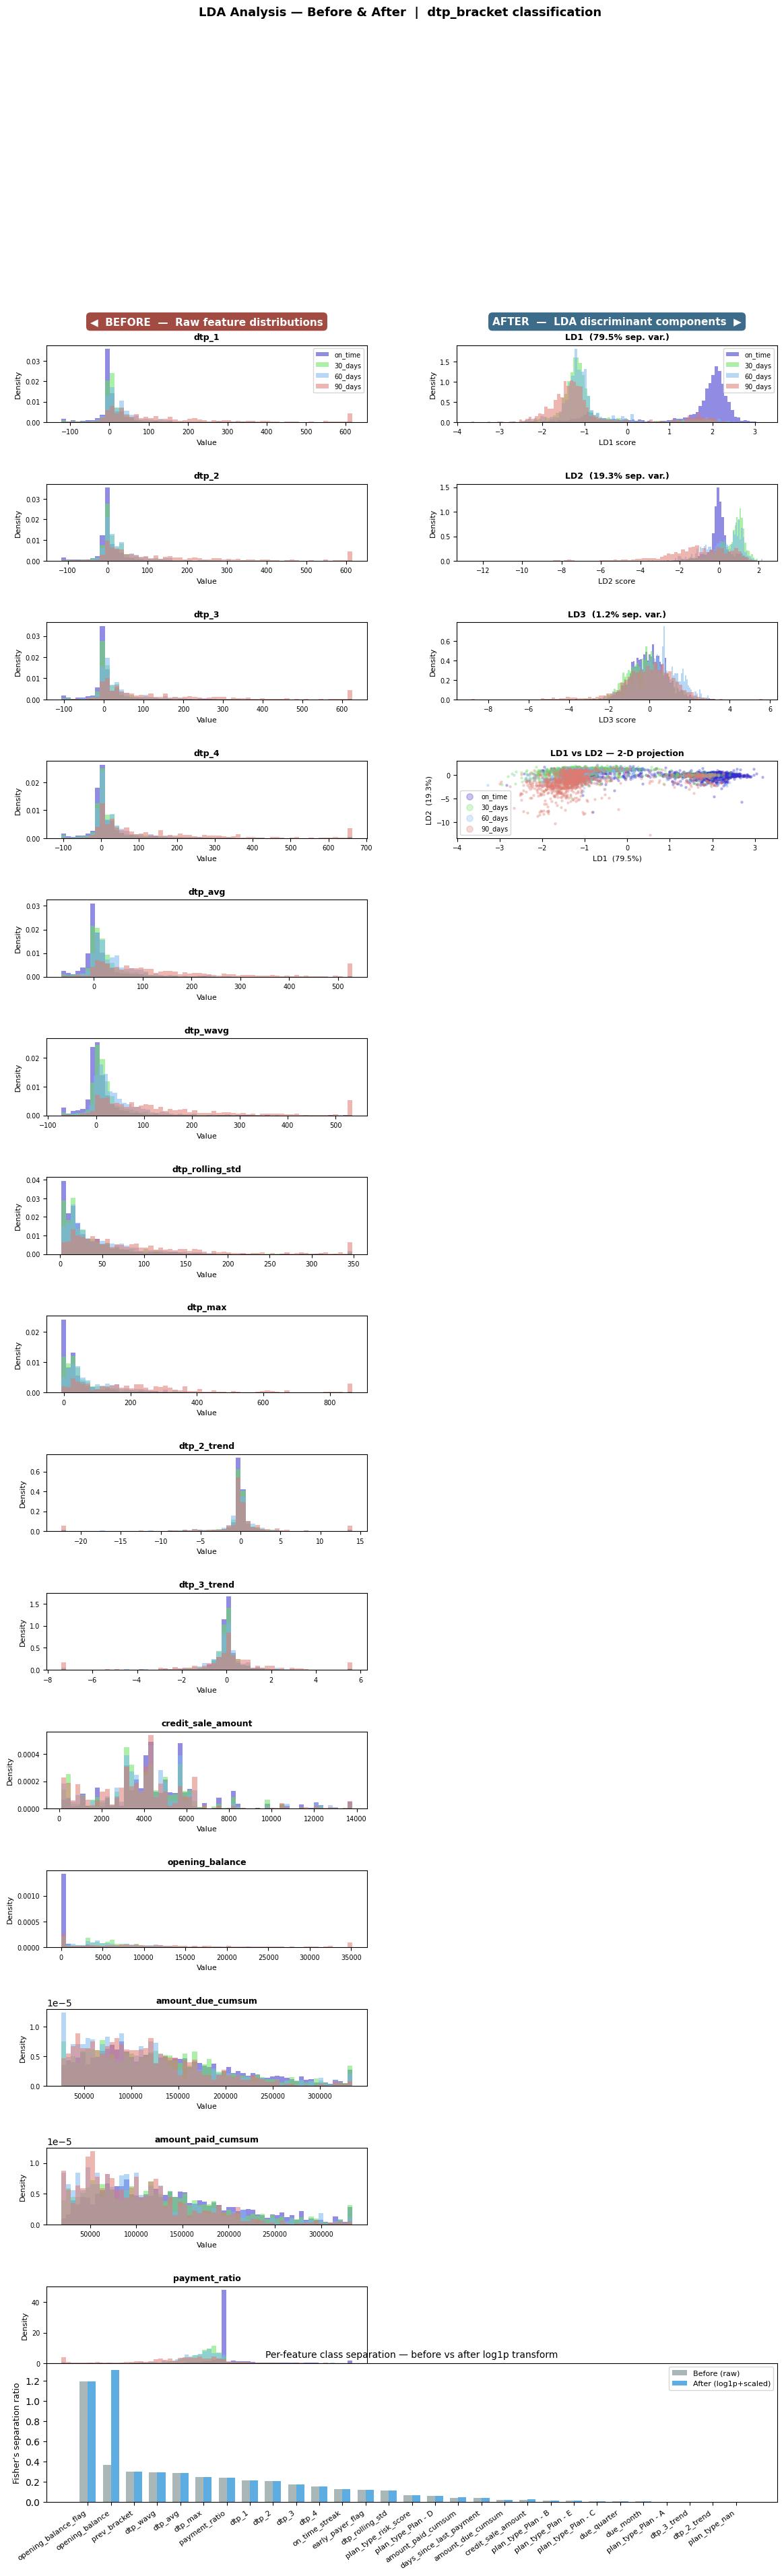


Saved → lda_before_after.png


(Pipeline(steps=[('scaler', StandardScaler()),
                 ('lda', LinearDiscriminantAnalysis(n_components=3))]),
 array([[ 1.71097572, -0.29899538,  0.64305657],
        [ 1.5525202 , -0.0345341 , -0.41645105],
        [-0.32399784,  1.28838288, -0.13823405],
        ...,
        [-1.01532992,  0.31216549,  0.16425806],
        [-1.39996036,  0.92047245, -0.22533232],
        [ 2.21618161, -0.10695066,  0.09299413]], shape=(6450, 3)),
 array([0.79522115, 0.19255335, 0.01222551]),
                     feature    before     after  improvement_%
 0      opening_balance_flag  1.192663  1.192663       0.000000
 1           opening_balance  0.363706  1.305319     258.894041
 2              prev_bracket  0.300249  0.300249       0.000000
 3                  dtp_wavg  0.291680  0.291680       0.000000
 4                   dtp_avg  0.284761  0.284761       0.000000
 5                   dtp_max  0.246985  0.246985       0.000000
 6             payment_ratio  0.237275  0.237275       0.0000

In [18]:
run_lda_analysis(df_credit_sales)

### d. LDA (Delinquent)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BRACKET_COL  = 'dtp_bracket'

DTP_FEATURES = ['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 'dtp_avg', 'dtp_wavg']
FIN_FEATURES = ['credit_sale_amount', 'opening_balance',
                'amount_due_cumsum', 'amount_paid_cumsum']
ALL_FEATURES = DTP_FEATURES + FIN_FEATURES + ['payment_ratio']

BRACKET_ORDER  = ['30_days', '60_days', '90_days']  # on_time excluded
BRACKET_COLORS = {
    'on_time': '#2ecc71',
    '30_days': '#5dade2',
    '60_days': '#f0b27a',
    '90_days': '#e07b72',
}


# ─────────────────────────────────────────────
# DATA HELPERS
# ─────────────────────────────────────────────

def load_and_prepare(df):
    """Clean and split into X (float64) and y (bracket label)."""
    cols_needed = ALL_FEATURES + [BRACKET_COL]
    df_clean = df[cols_needed].dropna()
    df_clean = df_clean[df_clean[BRACKET_COL].isin(BRACKET_ORDER)]
    X = df_clean[ALL_FEATURES].astype(float).copy()
    y = df_clean[BRACKET_COL].copy()
    return X, y


def log1p_transform(X):
    """log1p-transform financial features; leave DTP features untouched."""
    X_t = X.astype(float).copy()
    for col in FIN_FEATURES:
        if col in X_t.columns:
            shift = abs(X_t[col].min()) if X_t[col].min() < 0 else 0
            X_t[col] = np.log1p(X_t[col] + shift)
    return X_t


def fit_lda(X, y):
    """Scale then fit LDA; return (pipeline, projected array, explained var ratio)."""
    n_components = min(len(BRACKET_ORDER) - 1, X.shape[1])   # max 3
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lda',    LinearDiscriminantAnalysis(n_components=n_components,
                                              solver='svd')),
    ])
    X_lda = pipe.fit_transform(X, y)
    evr   = pipe.named_steps['lda'].explained_variance_ratio_
    return pipe, X_lda, evr


def compute_class_separation(X, y):
    """Fisher between/within variance ratio per feature."""
    rows = []
    for col in X.columns:
        overall_mean = X[col].mean()
        classes      = y.unique()
        between = sum(
            (y == c).sum() * (X.loc[y == c, col].mean() - overall_mean) ** 2
            for c in classes
        ) / len(y)
        within = sum(
            X.loc[y == c, col].var() * (y == c).sum()
            for c in classes
        ) / len(y)
        rows.append({'feature': col,
                     'separation': between / within if within > 0 else 0})
    return pd.DataFrame(rows).sort_values('separation', ascending=False)


# ─────────────────────────────────────────────
# ATOMIC PLOT HELPERS
# ─────────────────────────────────────────────

def _draw_raw_hist(ax, col, y, feat, show_legend=False):
    """Overlapping density histogram for one raw feature."""
    col = col.astype(float)
    lo, hi = col.quantile(0.01), col.quantile(0.99)
    for bracket in BRACKET_ORDER:
        vals = col[y == bracket].clip(lo, hi)
        ax.hist(vals, bins=60, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_hist(ax, X_lda, y, evr, ld_idx, show_legend=False):
    """Density histogram for one LDA discriminant axis."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.hist(X_lda[mask, ld_idx], bins=80, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(f'LD{ld_idx+1}  ({evr[ld_idx]*100:.1f}% sep. var.)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'LD{ld_idx+1} score', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_scatter(ax, X_lda, y, evr):
    """LD1 vs LD2 2-D scatter coloured by bracket."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
                   s=5, alpha=0.28, color=BRACKET_COLORS[bracket],
                   label=bracket, rasterized=True)
    ax.set_xlabel(f'LD1  ({evr[0]*100:.1f}%)', fontsize=8)
    ld2_label = f'LD2  ({evr[1]*100:.1f}%)' if len(evr) > 1 else 'LD2'
    ax.set_ylabel(ld2_label, fontsize=8)
    ax.set_title('LD1 vs LD2 — 2-D projection', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, markerscale=3)
    ax.tick_params(labelsize=7)


def _col_header(ax, text, color):
    """Solid-background header label above an axis."""
    ax.annotate(text, xy=(0.5, 1.24), xycoords='axes fraction',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.4', fc=color,
                          alpha=0.85, ec='none'))


def _draw_separation_bar(ax, sep_before, sep_after):
    """Grouped bar chart: Fisher separation before vs after."""
    features = sep_before['feature'].tolist()
    x, w     = np.arange(len(features)), 0.35
    b_vals   = sep_before.set_index('feature').loc[features, 'separation'].values
    a_vals   = sep_after.set_index('feature').loc[features,  'separation'].values
    ax.bar(x - w/2, b_vals, w, label='Before (raw)',         color='#aab7b8')
    ax.bar(x + w/2, a_vals, w, label='After (log1p+scaled)', color='#5dade2')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel("Fisher's separation ratio", fontsize=9)
    ax.set_title("Per-feature class separation — before vs after log1p transform",
                 fontsize=10)
    ax.legend(fontsize=8)


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run_lda_analysis_delinquent(df):
    """
    Two-column layout — one feature per row:

        LEFT  column  =  BEFORE  (raw histogram, p1–p99 clipped)
        RIGHT column  =  AFTER   (LDA component histogram)

    Feature rows:
        Rows 0–5   : dtp_1, dtp_2, dtp_3, dtp_4, dtp_avg, dtp_wavg
        Rows 6–10  : credit_sale_amount, opening_balance,
                     amount_due_cumsum, amount_paid_cumsum, payment_ratio

    Extra rows:
        Row 11 : [note | LD1 vs LD2 scatter]
        Row 12 : Fisher separation bar  (spans both columns)
    """
    # ── data ───────────────────────────────────
    X_raw, y         = load_and_prepare(df)
    X_t              = log1p_transform(X_raw)
    pipe, X_lda, evr = fit_lda(X_t, y)

    # console report
    print(f"\n{'='*55}")
    print("  LDA — Explained separation variance")
    print(f"{'='*55}")
    for i, v in enumerate(evr, 1):
        print(f"  LD{i}: {'█'*int(v*40):<40}  {v*100:.1f}%")
    print(f"{'='*55}\n")

    sep_before = compute_class_separation(X_raw, y)
    sep_after  = compute_class_separation(X_t,   y)
    merged = (sep_before.rename(columns={'separation': 'before'})
                         .merge(sep_after.rename(columns={'separation': 'after'}),
                                on='feature'))
    merged['improvement_%'] = ((merged['after'] - merged['before'])
                               / merged['before'].replace(0, np.nan) * 100)
    print(merged.to_string(index=False))

    # ── grid ───────────────────────────────────
    fin_plus  = FIN_FEATURES + ['payment_ratio']    # 5 features
    all_feats = DTP_FEATURES + fin_plus             # 11 total
    n_feats   = len(all_feats)
    n_ld      = X_lda.shape[1]                      # 3 at most

    # Right column content (after):
    #   Row 0        → LD1 histogram
    #   Row 1        → LD2 histogram
    #   Row 2        → LD3 histogram
    #   Row 3        → LD1 vs LD2 scatter  (spans remaining right cells via axis('off'))
    #   Rows 4–10    → empty (right side blank, left keeps all raw features)
    # Bottom row     → Fisher bar spanning both columns

    NROWS = n_feats + 1    # 11 feature rows + 1 bar row
    NCOLS = 2

    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(14, NROWS * 2.6),
        gridspec_kw={'hspace': 0.80, 'wspace': 0.28}
    )
    fig.suptitle(
        "LDA Analysis — Delinquent Only (30 / 60 / 90 days)  |  on_time excluded",
        fontsize=13, fontweight='bold', y=1.001
    )

    # column header badges on the first row
    _col_header(axes[0, 0], "◀  BEFORE  —  Raw feature distributions", '#922b21')
    _col_header(axes[0, 1], "AFTER  —  LDA discriminant components  ▶", '#1a5276')

    # ── LEFT column: all 11 raw feature histograms ──
    for i, feat in enumerate(all_feats):
        _draw_raw_hist(axes[i, 0], X_raw[feat], y, feat,
                       show_legend=(i == 0))

    # ── RIGHT column ────────────────────────────────
    # Rows 0–(n_ld-1): one LD histogram each
    for ld_idx in range(n_ld):
        _draw_ld_hist(axes[ld_idx, 1], X_lda, y, evr, ld_idx,
                      show_legend=(ld_idx == 0))

    # Row n_ld: LD1 vs LD2 scatter
    _draw_ld_scatter(axes[n_ld, 1], X_lda, y, evr)

    # Rows (n_ld+1) onward on the right: turn off (left keeps raw hists)
    for i in range(n_ld + 1, n_feats):
        axes[i, 1].axis('off')

    # ── Fisher bar row — spans both columns ─────────
    br = n_feats
    for c in range(NCOLS):
        axes[br, c].axis('off')

    pos_l  = axes[br, 0].get_position()
    pos_r  = axes[br, 1].get_position()
    bar_ax = fig.add_axes((
        pos_l.x0,
        pos_l.y0,
        pos_r.x1 - pos_l.x0,
        pos_l.height * 1.8
    ))
    _draw_separation_bar(bar_ax, sep_before, sep_after)

    plt.savefig('lda_delinquent_only.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved → lda_delinquent_only.png")

    return pipe, X_lda, evr, merged


# ─────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────
# pipe, X_lda, evr, sep_df = run_lda_analysis(df_credit_sales)  # delinquent only
#
# Inject LD components back into your dataframe for modelling:
#   X_raw, y = load_and_prepare(df_credit_sales)
#   X_t      = log1p_transform(X_raw)
#   comps    = pipe.transform(X_t)
#   for i in range(comps.shape[1]):
#       df_credit_sales.loc[X_raw.index, f'LD{i+1}'] = comps[:, i]


  LDA — Explained separation variance
  LD1: ██████████████████████████████████████    95.9%
  LD2: █                                         4.1%



           feature   before    after  improvement_%
          dtp_wavg 0.226306 0.226306       0.000000
           dtp_avg 0.222605 0.222605       0.000000
             dtp_2 0.167918 0.167918       0.000000
             dtp_1 0.165470 0.165470       0.000000
             dtp_3 0.139237 0.139237       0.000000
             dtp_4 0.128412 0.128412       0.000000
   opening_balance 0.121562 0.000534     -99.561020
     payment_ratio 0.073670 0.073670       0.000000
amount_paid_cumsum 0.025726 0.024540      -4.610788
 amount_due_cumsum 0.016005 0.012960     -19.028934
credit_sale_amount 0.002423 0.004119      69.979449


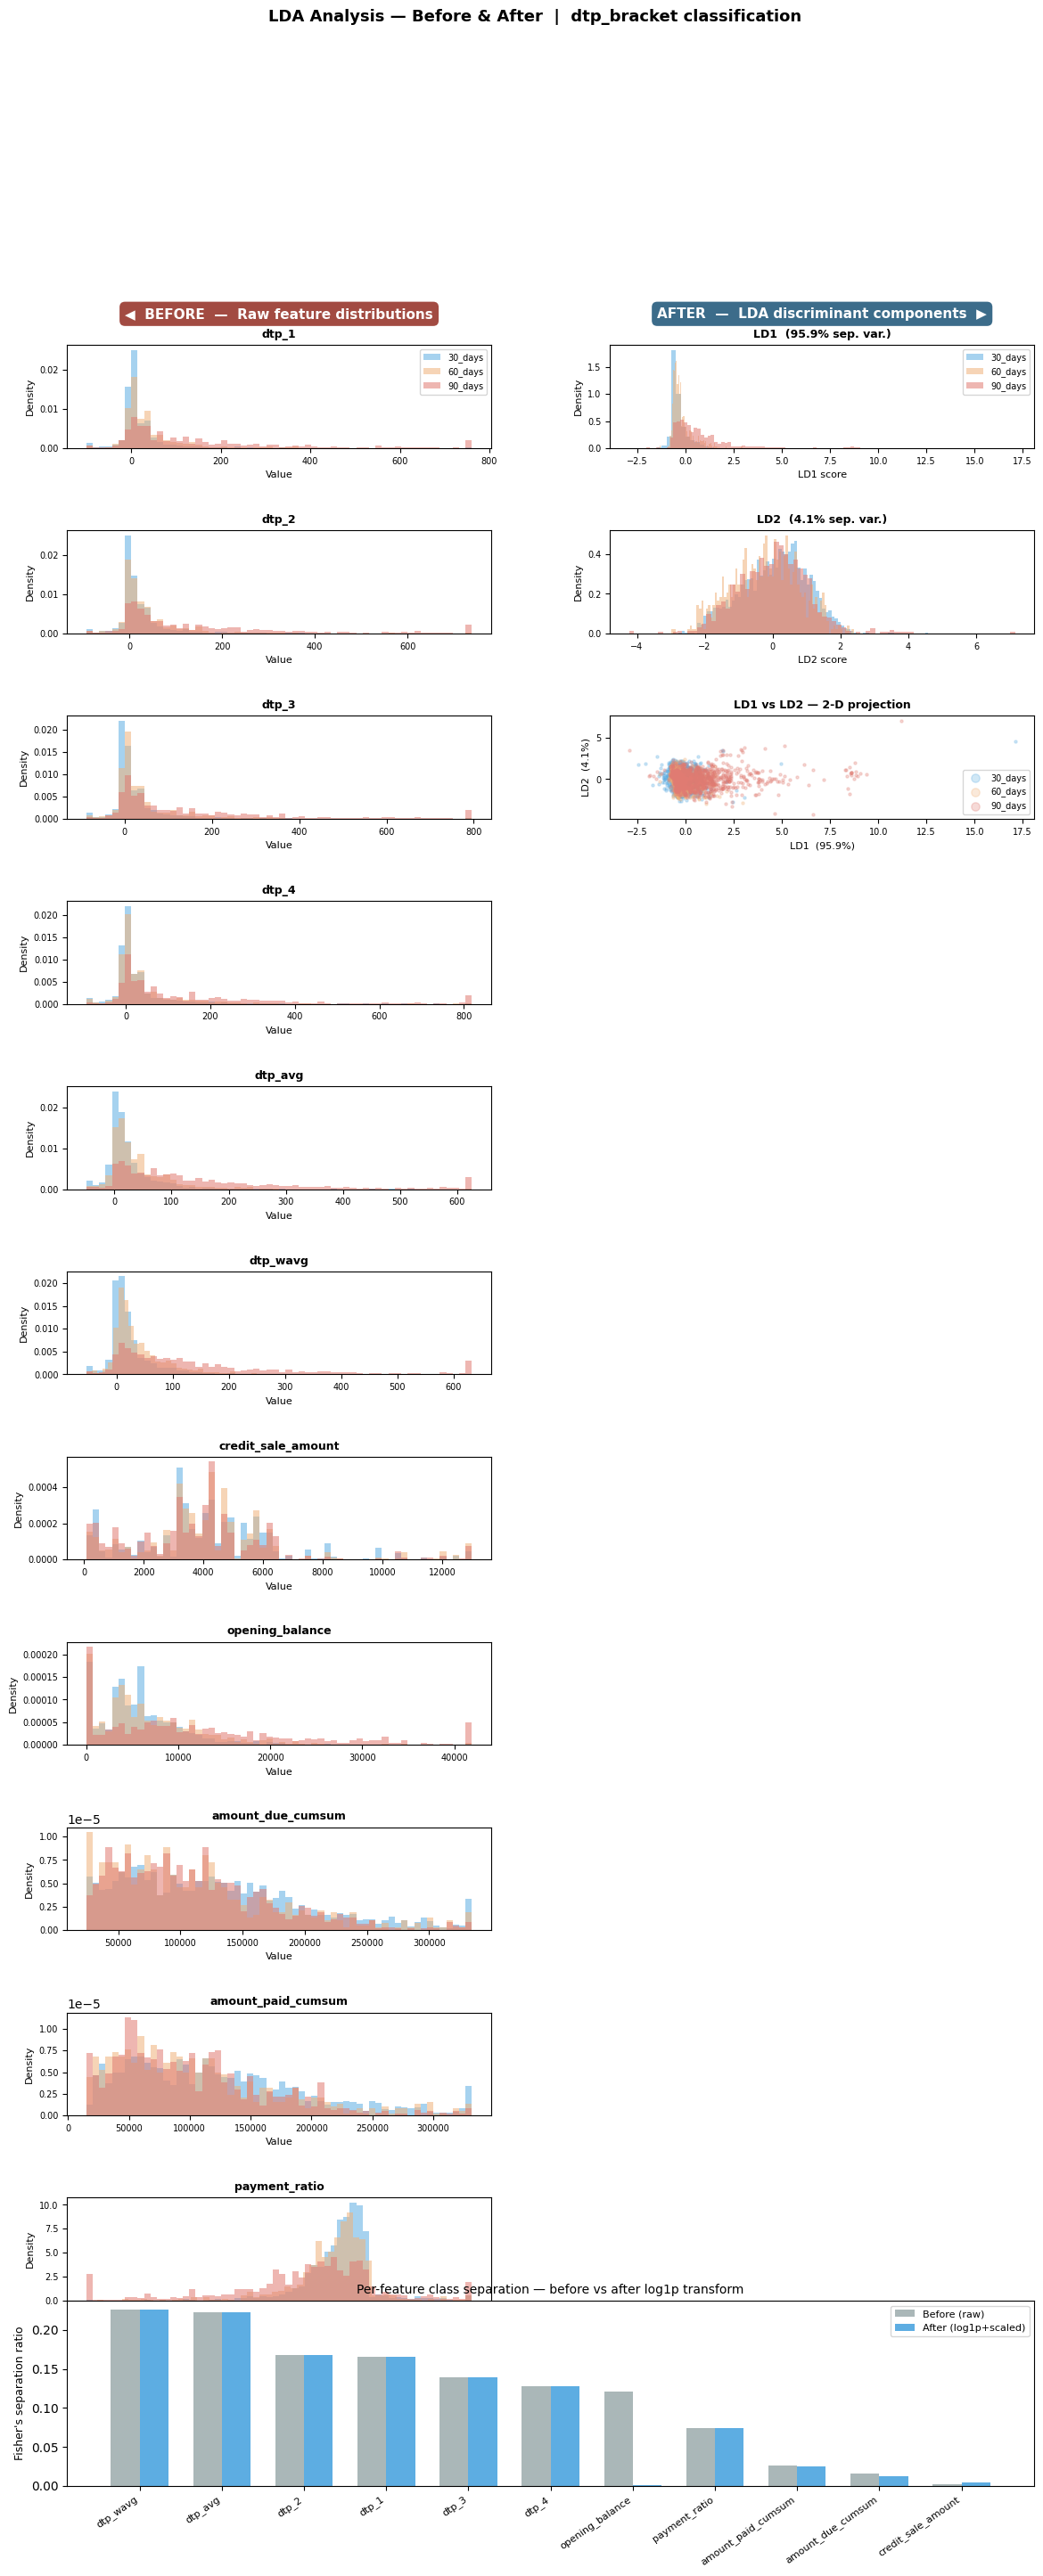


Saved → lda_before_after.png


(Pipeline(steps=[('scaler', StandardScaler()),
                 ('lda', LinearDiscriminantAnalysis(n_components=2))]),
 array([[ 0.41954244, -0.19974327],
        [-0.13068   ,  0.27555057],
        [-0.41480841,  0.77359929],
        ...,
        [-0.44566952,  1.23606727],
        [-0.52949772,  1.44298539],
        [-0.60987601,  1.04770023]], shape=(3874, 2)),
 array([0.95852993, 0.04147007]),
                feature    before     after  improvement_%
 0             dtp_wavg  0.226306  0.226306       0.000000
 1              dtp_avg  0.222605  0.222605       0.000000
 2                dtp_2  0.167918  0.167918       0.000000
 3                dtp_1  0.165470  0.165470       0.000000
 4                dtp_3  0.139237  0.139237       0.000000
 5                dtp_4  0.128412  0.128412       0.000000
 6      opening_balance  0.121562  0.000534     -99.561020
 7        payment_ratio  0.073670  0.073670       0.000000
 8   amount_paid_cumsum  0.025726  0.024540      -4.610788
 9    amo

In [20]:
run_lda_analysis(df_credit_sales)

# D. Machine Learning Pipelines

## 1. Single model trainer

### a. Data preparation

In [21]:
# ── 1. Load settings ────────────────────────────────────────────────────────────────────────
from datetime import datetime
from types import SimpleNamespace
from utils.data_loaders.read_settings_json import read_settings_json

settings = read_settings_json(file_path="settings.json")
observation_end = datetime.strptime(settings['Training']['observation_end'], "%Y/%m/%d")
target_feature = settings["Training"]["target_feature"]
test_size = float(settings["Training"]["test_size"])

# SimpleNamespace is picklable by multiprocessing workers (class defined in __main__ is not).
args = SimpleNamespace(
    observation_end = observation_end,
    target_feature  = target_feature,
    test_size       = test_size,                                          # Test size in %
    parameters_dir  = settings['Training']['MODEL_PARAMETERS'],
)



# ── 2. Load the invoice dataset ─────────────────────────────────────────────────────────
from feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(
    df_revenues, df_enrollees, args,
    drop_demographic_columns=True,
    drop_fully_paid_invoices=False,
    drop_helper_columns=True,
    drop_missing_dtp=True,
    add_streak_features=True,
    exclude_school_years=[2016, 2017, 2018],
    winsorise_dtp=True)
df_credit_sales = cs.show_data()



# ── 3. Load the dataset for machine learning and for survival analysis ───────────────────
survival_columns = ['days_elapsed_until_fully_paid', 'censor']
non_survival_columns = ['due_date', 'dtp_bracket']


df_data = df_credit_sales[df_credit_sales['censor'] == 1].copy()
df_data.drop(columns=survival_columns, inplace=True)

df_data_surv = df_credit_sales.drop(columns=non_survival_columns)



# ── 4. Cox Best Parameters (hardcoded from prior tuning run) ──────────────────────────────
from machine_learning.utils.features.adjust_survival_time_periods import adjust_payment_period
from machine_learning.utils.features.get_slope_time_points import get_slope_timepoints

X_surv = df_data_surv.drop(columns=survival_columns)
T      = adjust_payment_period(df_data_surv["days_elapsed_until_fully_paid"])   
E      = df_data_surv["censor"]

# Best parameters confirmed by prior tuning run (C-index: 0.7817)
# Hardcoded to skip the 90-fit CV sweep and save ~3–5 minutes per run
best_surv_parameters = {"alpha": 0.05, "l1_ratio": 0.5}
best_time_points = get_slope_timepoints(T, E, n_points=9)
args.time_points = best_time_points

class _TunerStub:
    best_params_  = best_surv_parameters
    best_c_index_ = 0.7817

tuner = _TunerStub()



# ── 5. Data Preparation ──────────────────────────────────────────────────────────────
from machine_learning.utils.data.data_preparation import DataPreparer

preparer = DataPreparer(
    df_data,
    target_feature=args.target_feature,
    test_size=args.test_size
)
preparer.encode_labels().train_test_split().resample(balance_strategy="smote_tomek")

X_train = preparer.X_train
X_test = preparer.X_test
y_train = preparer.y_train
y_test = preparer.y_test



# ── 6. Generate survival features ──────────────────────────────────────────────────────────────
from machine_learning.utils.features.generate_survival_features import generate_survival_features

X_survival_train, X_survival_test = generate_survival_features(
    X_surv, T, E, X_train, X_test,
    best_params=best_surv_parameters,
    time_points=best_time_points
)


Single due date records:   10377
Multiple due date records: 289


Excluded school years [2016, 2017, 2018]: removed 234 rows, 10177 remaining.
Dropped 3650 invoices with missing DTP values. Remaining: 6527


Partitioning datasets based on due_date (cut-off: 2025-03-07 — train: due_date < cut-off, test: due_date >= cut-off)...
Applying smote_tomek...


### b. Train models (Ada Boost)

In [22]:
model_parameters = {
    "learning_rate": 0.1,
    "n_estimators": 50,
    "random_state": 42
}

In [23]:
from machine_learning import AdaBoostPipeline

pipeline = AdaBoostPipeline(
    X_train, X_test, y_train, y_test,
    args,
    model_parameters
)

# Capture results from pipeline
result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
selected_features = pipeline.features

print(f'Accuracy: {result['accuracy']}')
print(f'Precission: {result['precision_macro']}')
print(f'Recall: {result['recall_macro']}')
print(f'F1: {result['f1_macro']}')
print(f'AUC: {result['roc_auc_macro']}')

Accuracy: 0.7063697566027964
Precission: 0.5958875266120093
Recall: 0.5658618689474402
F1: 0.5578475817663362
AUC: 0.8314966995678342


In [24]:
selected_features.weights

{'credit_sale_amount': 0.0,
 'dtp_1': 0.0,
 'dtp_2': 0.0,
 'dtp_3': 0.0,
 'dtp_4': 0.0,
 'dtp_avg': 0.203404,
 'dtp_wavg': 0.074007,
 'dtp_2_trend': 0.0,
 'dtp_3_trend': 0.0,
 'days_since_last_payment': 0.0,
 'amount_due_cumsum': 0.0,
 'amount_paid_cumsum': 0.0,
 'opening_balance': 0.722589,
 'plan_type_Plan - A': 0.0,
 'plan_type_Plan - B': 0.0,
 'plan_type_Plan - C': 0.0,
 'plan_type_Plan - D': 0.0,
 'plan_type_Plan - E': 0.0,
 'plan_type_nan': 0.0,
 'due_month': 0.0,
 'due_quarter': 0.0,
 'opening_balance_flag': 0.0,
 'payment_ratio': 0.0,
 'early_payer_flag': 0.0,
 'dtp_rolling_std': 0.0,
 'dtp_max': 0.0,
 'plan_type_risk_score': 0.0}

### b. Train models (Two Step)

In [25]:
model_parameters = {
    "stage1": {
        "colsample_bytree": 0.8,
        "learning_rate": 0.01,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 300,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "subsample": 0.8
    },
    "stage2": {
        "learning_rate": 0.1,
        "n_estimators": 50
    }
}

In [26]:
from machine_learning import TwoStagePipeline
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

pipeline = TwoStagePipeline(
    X_survival_train, X_survival_test, y_train, y_test,
    args,
    stage1_estimator=XGBClassifier(**model_parameters["stage1"]),
    stage2_estimator=AdaBoostClassifier(**model_parameters["stage2"]),
    use_lda = [True, False],
    lda_mode = "append",
)

result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
selected_features = pipeline.features

In [27]:
result.keys()

dict_keys(['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro', 'confusion_matrix', 'roc_curve', 'pr_curve'])

In [28]:
print(f'Accuracy: {result['accuracy']}')
print(f'Precission: {result['precision_macro']}')
print(f'Recall: {result['recall_macro']}')
print(f'F1: {result['f1_macro']}')
print(f'AUC: {result['roc_auc_macro']}')

Accuracy: 0.7446918694976696
Precission: 0.5940510825509755
Recall: 0.5810738131220499
F1: 0.5766581860761854
AUC: 0.883611765869867


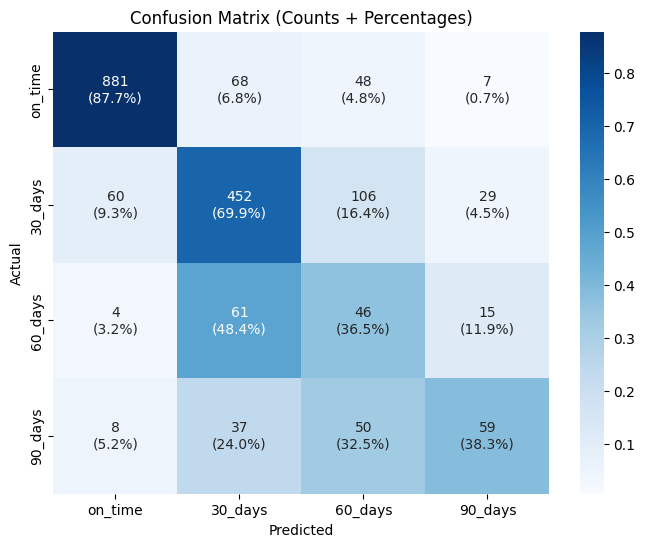

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix (convert to NumPy array)
cm = np.array(result['confusion_matrix'])

# Class mapping
class_mapping = {'on_time': 0, '30_days': 1, '60_days': 2, '90_days': 3}
labels = list(class_mapping.keys())

# Normalize by row (true class)
cm_normalized = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

# Create annotations with both raw counts and percentages
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_normalized[i, j]:.1%})"

# Plot heatmap using normalized values for color
plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=annot, fmt="", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts + Percentages)")
plt.show()

In [30]:
selected_features

FeatureInfo(
  method      : Two-stage independent feature selection + Stage-1 LDA
  parameters  : threshold='median', stage1_features=24, stage2_features=48
  selected    : 48 features
    · credit_sale_amount
    · dtp_1
    · dtp_2
    · dtp_3
    · dtp_4
    · dtp_avg
    · dtp_wavg
    · dtp_2_trend
    · dtp_3_trend
    · days_since_last_payment
    · amount_due_cumsum
    · amount_paid_cumsum
    · opening_balance
    · plan_type_Plan - A
    · plan_type_Plan - B
    · plan_type_Plan - C
    · plan_type_Plan - D
    · plan_type_Plan - E
    · plan_type_nan
    · due_month
    · due_quarter
    · opening_balance_flag
    · payment_ratio
    · early_payer_flag
    · dtp_rolling_std
    · dtp_max
    · plan_type_risk_score
    · surv_prob_1
    · surv_prob_16
    · surv_prob_30
    · surv_prob_58
    · surv_prob_76
    · surv_prob_118
    · surv_prob_150
    · surv_prob_306
    · surv_prob_322
    · cum_hazard_1
    · cum_hazard_16
    · cum_hazard_30
    · cum_hazard_58
    · cum_

In [31]:
assert selected_features.weights is not None
df = pd.DataFrame.from_dict(selected_features.weights['stage_1'], orient='index', columns=['value'])
df['value'].sum()

np.float64(0.9999990000000002)

## 2. Multiple model trainer

In [32]:
from machine_learning import (
    AdaBoostPipeline,
    DecisionTreePipeline,
    GaussianNaiveBayesPipeline,
    KNearestNeighborPipeline,
    RandomForestPipeline,
    XGBoostPipeline,
    OrdinalPipeline,
    TwoStagePipeline,
)

models = {
    "ada_boost":           AdaBoostPipeline,
    "decision_tree":       DecisionTreePipeline,
    "gaussian_naive_bayes": GaussianNaiveBayesPipeline,
    "knn":                 KNearestNeighborPipeline,
    "random_forest":       RandomForestPipeline,
    "xgboost":             XGBoostPipeline,
    "ordinal":             OrdinalPipeline,    # expands to ordinal_xgboost, ordinal_random_forest, ordinal_ada_boost
    "two_stage":           TwoStagePipeline,   # expands to 6 xgb/rf/ada combinations
}

# XGBoost uses GPU acceleration — must run sequentially to avoid CUDA context
# conflicts in the thread pool. The runner auto-extends this list to include
# all expanded model names containing 'xgb' (ordinal_xgboost, two_stage_xgb_*,
# two_stage_ada_xgb), so only the base alias is needed here.
do_not_parallel_compute = ['xgboost']


In [33]:
from machine_learning.utils.features.generate_thresholds import generate_thresholds

# Full strategy matrix: no balancing baseline + all SMOTE variants + hybrid threshold sweep
# smote_enn removed — prior runs showed it consistently underperforms borderline_smote
balance_strategies = ["none", "smote", "borderline_smote", "smote_tomek", "hybrid"]

# Hybrid threshold grid: three representative thresholds (threshold choice is a second-order effect)
thresholds = [0.5, 0.7, 0.9]


In [34]:
# To silence the error when running knn:
# UserWarning: Could not find the number of physical cores for the following reason:
# [WinError 2]
import os

os.environ['OMP_NUM_THREADS'] = '16'

In [35]:
# (Single-threaded runner removed — parallel runner in SurvivalExperimentRunner is the only path)


In [36]:
# Survival related features
drop_columns = ['censor', 'days_elapsed_until_fully_paid']

# Only extract invoices with payments
df_data = df_credit_sales[df_credit_sales['censor'] == 1]

df_data = df_data.drop(columns=drop_columns)

# Drop invoices with missing critical features
df_data.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data

,credit_sale_amount,due_date,dtp_1,dtp_2,dtp_3,dtp_4,dtp_avg,dtp_wavg,dtp_2_trend,dtp_3_trend,...,plan_type_nan,dtp_bracket,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,dtp_rolling_std,dtp_max,plan_type_risk_score
1675,2800.0,2022-02-07,24,-5,-2,79,24.00,15.6,-0.491525,-0.412698,...,0.0,on_time,2,1,0,1.000000,0.0,38.910153,79,0
1756,2800.0,2022-04-04,-9,24,-5,-2,2.00,2.4,0.589286,0.034783,...,0.0,on_time,4,2,0,1.000000,1.0,14.944341,24,0
9797,4700.0,2026-02-06,-2,-28,-14,-7,-12.75,-12.7,-0.412698,-0.190476,...,0.0,on_time,2,1,1,0.988662,1.0,11.295279,-2,0
10084,4933.0,2026-03-06,-8,-2,-28,-14,-13.00,-10.8,0.214286,-0.219780,...,0.0,on_time,3,1,0,1.000000,1.0,11.135529,-2,0
639,2900.0,2019-12-06,33,193,152,284,165.50,129.9,6.400000,0.619792,...,0.0,30_days,12,4,1,0.905309,0.0,104.142531,284,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9796,5800.0,2026-02-06,34,34,24,12,26.00,29.8,0.000000,-0.158730,...,0.0,30_days,2,1,1,0.972245,0.0,10.456258,34,0
9881,1500.0,2026-02-18,3,34,34,24,23.75,20.6,2.583333,0.413333,...,0.0,60_days,2,1,1,0.992873,0.0,14.614491,34,0
9960,400.0,2026-03-05,33,3,34,34,26.00,24.3,-2.000000,0.037037,...,0.0,30_days,3,1,1,0.990990,0.0,15.340578,34,0
10297,5800.0,2026-03-06,6,33,3,34,19.00,16.3,27.000000,-0.187500,...,0.0,30_days,3,1,1,0.964462,0.0,16.792856,34,0


In [37]:
import time
from machine_learning.utils.training.run_models_parallel import SurvivalExperimentRunner
from machine_learning.utils.io.save_results_to_folder import save_training_results

# Record start time
_train_start = time.time()
_train_start_iso = time.strftime("%Y-%m-%dT%H:%M:%S", time.localtime(_train_start))

# Create an experiment runner instance
runner = SurvivalExperimentRunner(
    df_data=df_data,
    df_data_surv=df_data_surv,
    models=models,
    balance_strategies=balance_strategies,
    args=args,
    best_parameters=best_surv_parameters,
    thresholds=thresholds,
    n_jobs=-1,
    do_not_parallel_compute=do_not_parallel_compute,
    feature_selection_baseline=True,
    feature_selection_enhanced=True,
    checkpoint_path="annesnotes/logs/_checkpoint.pkl",
)

# Run all experiments — returns (results_df, class_mappings)
df_results, class_mappings = runner.run()

# Record end time
_train_end = time.time()
_train_end_iso = time.strftime("%Y-%m-%dT%H:%M:%S", time.localtime(_train_end))
_elapsed_s = int(_train_end - _train_start)
_elapsed_str = f"{_elapsed_s // 3600}h {(_elapsed_s % 3600) // 60}m {_elapsed_s % 60}s"
print(f"\nTotal training time: {_elapsed_str}")

# Save results to a new dated folder under Results/
survival_results_dict = {
    "best_c_index":      tuner.best_c_index_,
    "best_parameters":   best_surv_parameters,
    "time_points":       best_time_points,
}

metadata, run_folder = save_training_results(
    model_results_df     = df_results,
    survival_results_dict= survival_results_dict,
    class_mappings_dict  = class_mappings,
    base_output_folder   = settings['Training']['RESULTS_ROOT'],
    model_names          = list(models.keys()),
    start_time           = _train_start_iso,
    end_time             = _train_end_iso,
    total_run_time       = _elapsed_str,
    format               = "sqlite",
)

print(f"Results saved → {run_folder}")


[dataset] Preparing: none ...


[dataset]   Generating survival features ...


[dataset]   Done (8s)


[dataset] Preparing: smote ...


[dataset]   Generating survival features ...


...

[1091/1092] two_stage_ada_xgb | Elapsed: 206m 08s | ETA: ~11s remaining


[1092/1092] two_stage_ada_xgb | Elapsed: 206m 22s | ETA: ~0s remaining


[checkpoint] Run complete — checkpoint removed.



Total training time: 3h 27m 31s


Results saved as sqlite to Results\2026_04_18_02
Results saved → Results\2026_04_18_02


In [38]:
df_results

,model,undersample_threshold,parameters,balance_strategy,baseline_accuracy,baseline_precision_macro,baseline_recall_macro,baseline_f1_macro,baseline_roc_auc_macro,baseline_confusion_matrix,...,enhanced_recall_macro,enhanced_f1_macro,enhanced_roc_auc_macro,enhanced_confusion_matrix,enhanced_roc_curve,enhanced_pr_curve,enhanced_feature_method,enhanced_feature_parameters,enhanced_feature_selected,enhanced_feature_weights
0,gaussian_naive_bayes,NaN,"[('var_smoothing', 0.01)]",none,0.621440,0.433870,0.388544,0.381157,0.671520,"[[979, 21, 0, 4], [447, 173, 0, 27], [59, 53, ...",...,0.388897,0.381424,0.674516,"[[977, 23, 0, 4], [449, 171, 0, 27], [59, 53, ...","{'0': {'fpr': [0.0, 0.0010787486515641855, 0.0...","{'0': {'precision': [0.5199378560331435, 0.520...",GaussianNB influence score,top_k=None,"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 1.7e-05, 'dtp_1': 4e-06..."
1,gaussian_naive_bayes,NaN,"[('var_smoothing', 0.001)]",none,0.659762,0.434951,0.427308,0.418255,0.722326,"[[968, 31, 0, 5], [349, 251, 0, 47], [28, 77, ...",...,0.427582,0.419197,0.735416,"[[966, 33, 0, 5], [349, 253, 0, 45], [29, 76, ...","{'0': {'fpr': [0.0, 0.0010787486515641855, 0.0...","{'0': {'precision': [0.5199378560331435, 0.520...",GaussianNB influence score,top_k=None,"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 7.4e-05, 'dtp_1': 4e-05..."
2,gaussian_naive_bayes,NaN,"[('var_smoothing', 0.0001)]",none,0.664940,0.437199,0.430209,0.422134,0.733630,"[[966, 34, 0, 4], [337, 264, 0, 46], [28, 76, ...",...,0.437322,0.426317,0.769678,"[[957, 40, 2, 5], [330, 263, 2, 52], [28, 73, ...","{'0': {'fpr': [0.0, 0.0010787486515641855, 0.0...","{'0': {'precision': [0.5199378560331435, 0.520...",GaussianNB influence score,top_k=None,"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 0.000113, 'dtp_1': 0.00..."
3,decision_tree,NaN,"[('max_depth', 10), ('min_samples_leaf', 1)]",none,0.700673,0.498736,0.516926,0.504047,0.788489,"[[832, 88, 42, 42], [59, 438, 63, 87], [4, 80,...",...,0.508803,0.487604,0.786196,"[[833, 81, 34, 56], [40, 421, 55, 131], [2, 82...","{'0': {'fpr': [0.0, 0.025889967637540454, 0.02...","{'0': {'precision': [0.5199378560331435, 0.593...",Gini Importance,threshold='median',"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 0.031858, 'dtp_1': 0.03..."
4,gaussian_naive_bayes,NaN,"[('var_smoothing', 1e-06)]",none,0.601243,0.456025,0.385328,0.383938,0.772786,"[[961, 29, 7, 7], [476, 145, 8, 18], [45, 71, ...",...,0.440250,0.450810,0.789675,"[[892, 94, 11, 7], [296, 319, 12, 20], [28, 88...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.00107874865156...","{'0': {'precision': [0.5199378560331435, 0.520...",GaussianNB influence score,top_k=None,"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 0.00012, 'dtp_1': 0.008..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,two_stage_ada_xgb,0.9,"stage1={'learning_rate': 0.1, 'n_estimators': ...",hybrid,0.699120,0.523838,0.529925,0.522972,0.810400,"[[867, 56, 52, 29], [98, 387, 108, 54], [6, 74...",...,0.530501,0.521911,0.798101,"[[869, 56, 47, 32], [99, 383, 109, 56], [6, 73...","{'0': {'fpr': [0.0, 0.0, 0.0010787486515641855...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=48, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.0, 'dtp_1..."
1088,two_stage_ada_xgb,0.9,"stage1={'learning_rate': 0.1, 'n_estimators': ...",hybrid,0.719316,0.545875,0.542420,0.540294,0.831841,"[[927, 35, 25, 17], [163, 362, 73, 49], [11, 6...",...,0.527485,0.526783,0.829258,"[[926, 38, 23, 17], [171, 352, 77, 47], [12, 6...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=48, stage2...","[credit_sale_amoun

In [39]:
df_results.sort_values(by='enhanced_accuracy', ascending=False)

,model,undersample_threshold,parameters,balance_strategy,baseline_accuracy,baseline_precision_macro,baseline_recall_macro,baseline_f1_macro,baseline_roc_auc_macro,baseline_confusion_matrix,...,enhanced_recall_macro,enhanced_f1_macro,enhanced_roc_auc_macro,enhanced_confusion_matrix,enhanced_roc_curve,enhanced_pr_curve,enhanced_feature_method,enhanced_feature_parameters,enhanced_feature_selected,enhanced_feature_weights
682,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.05,...",none,0.791818,0.547288,0.538893,0.531589,0.880490,"[[891, 105, 0, 8], [44, 581, 0, 22], [5, 112, ...",...,0.542946,0.535038,0.878643,"[[893, 102, 0, 9], [39, 586, 0, 22], [5, 112, ...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.023234, '..."
683,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.05,...",none,0.787157,0.527693,0.541601,0.530425,0.884684,"[[909, 85, 0, 10], [67, 547, 0, 33], [5, 106, ...",...,0.546590,0.534684,0.882045,"[[907, 87, 0, 10], [57, 557, 0, 33], [5, 106, ...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.023234, '..."
685,two_stage_xgb_ada,NaN,"stage1={'max_depth': 5, 'learning_rate': 0.05,...",none,0.787675,0.529540,0.545697,0.532431,0.882238,"[[891, 103, 0, 10], [47, 565, 0, 35], [4, 107,...",...,0.546693,0.533496,0.884438,"[[895, 98, 0, 11], [48, 565, 0, 34], [5, 106, ...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.023891, '..."
748,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.05,...",smote,0.783014,0.564347,0.553747,0.542842,0.874695,"[[878, 106, 6, 14], [41, 562, 4, 40], [4, 100,...",...,0.557697,0.547023,0.873159,"[[883, 103, 6, 12], [34, 569, 4, 40], [4, 100,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.014174, '..."
684,two_stage_xgb_ada,NaN,"stage1={'max_depth': 5, 'learning_rate': 0.01,...",none,0.786639,0.539281,0.537503,0.529384,0.881624,"[[891, 103, 0, 10], [53, 569, 0, 25], [5, 112,...",...,0.538138,0.529299,0.883441,"[[892, 101, 0, 11], [51, 570, 0, 26], [5, 112,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.018672, '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,gaussian_naive_bayes,NaN,"[('var_smoothing', 1e-09)]",borderline_smote,0.581046,0.467776,0.425869,0.412623,0.753301,"[[937, 23, 31, 13], [468, 95, 58, 26], [44, 41...",...,0.442074,0.410796,0.727993,"[[335, 576, 68, 25], [43, 474, 93, 37], [5, 72...","{'0': {'fpr': [0.0, 0.03344120819848975, 0.034...","{'0': {'precision': [0.5199378560331435, 0.520...",GaussianNB influence score,top_k=None,"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 0.000144, 'dtp_1': 0.01..."
280,gaussian_naive_bayes,NaN,"[('var_smoothing', 1e-08)]",smote_tomek,0.589850,0.489039,0.436801,0.425838,0.770541,"[[939, 20, 36, 9], [456, 108, 58, 25], [39, 41...",...,0.

In [40]:
df_results.sort_values(by='enhanced_precision_macro', ascending=False)

,model,undersample_threshold,parameters,balance_strategy,baseline_accuracy,baseline_precision_macro,baseline_recall_macro,baseline_f1_macro,baseline_roc_auc_macro,baseline_confusion_matrix,...,enhanced_recall_macro,enhanced_f1_macro,enhanced_roc_auc_macro,enhanced_confusion_matrix,enhanced_roc_curve,enhanced_pr_curve,enhanced_feature_method,enhanced_feature_parameters,enhanced_feature_selected,enhanced_feature_weights
660,two_stage_xgb_xgb,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.05,...",none,0.768514,0.493257,0.552567,0.517044,0.875156,"[[890, 72, 1, 41], [48, 512, 0, 87], [5, 96, 0...",...,0.559455,0.524236,0.874683,"[[892, 70, 0, 42], [43, 515, 0, 89], [5, 94, 1...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.023234, '..."
656,two_stage_xgb_xgb,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",none,0.772139,0.499501,0.556371,0.523523,0.872040,"[[891, 75, 1, 37], [60, 517, 0, 70], [4, 96, 0...",...,0.555186,0.522914,0.872525,"[[891, 72, 0, 41], [57, 513, 0, 77], [4, 94, 1...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.023189, '..."
107,ordinal_ada_boost,NaN,"[('learning_rate', 0.01), ('n_estimators', 150)]",none,0.752978,0.633521,0.564046,0.554201,0.852377,"[[859, 114, 1, 30], [88, 501, 4, 54], [7, 81, ...",...,0.564844,0.554690,0.842948,"[[856, 117, 1, 30], [84, 505, 4, 54], [4, 84, ...","{'0': {'fpr': [0.0, 0.10248112189859762, 0.104...","{'0': {'precision': [0.5199378560331435, 0.780...",Ordinal mean feature importances,threshold='median',"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 0.0, 'dtp_1': 0.001643,..."
652,two_stage_xgb_xgb,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",none,0.766960,0.498070,0.552369,0.521333,0.870890,"[[883, 87, 1, 33], [65, 516, 0, 66], [4, 96, 0...",...,0.550093,0.521596,0.872147,"[[887, 84, 1, 32], [61, 515, 0, 71], [4, 94, 1...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.021984, '..."
686,two_stage_ada_xgb,NaN,"stage1={'learning_rate': 0.01, 'n_estimators':...",none,0.745210,0.487775,0.528579,0.505287,0.829195,"[[848, 129, 1, 26], [77, 519, 0, 51], [4, 97, ...",...,0.532187,0.509566,0.829664,"[[848, 126, 1, 29], [76, 519, 0, 52], [4, 95, ...","{'0': {'fpr': [0.0, 0.0, 0.005393743257820928,...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=48, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.0, 'dtp_1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,ordinal_ada_boost,NaN,"[('learning_rate', 1.0), ('n_estimators', 150)]",smote_tomek,0.549974,0.227808,0.437613,0.284309,0.802028,"[[936, 0, 0, 68], [341, 0, 0, 306], [38, 0, 0,...",...,0.437852,0.287951,0.801566,"[[950, 0, 0, 54], [374, 0, 0, 273], [43, 0, 0,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Ordinal mean feature importances,threshold='median',"[credit_sale_amount, dtp_1, dtp_3, dtp_4, dtp_...","{'credit_sale_amount': 0.087943, 'dtp_1': 0.01..."
295,ordinal_ada_boost,NaN,"[('learning_rate', 1.0), ('n_estimators', 150)]",borderline_smote,0.547903,0.230889,0.447612,0.285828,0.824721,"[[924, 0, 0, 80], [323, 0, 0, 324], [31, 0, 0,...

In [41]:
df_results.sort_values(by='enhanced_f1_macro', ascending=False)

,model,undersample_threshold,parameters,balance_strategy,baseline_accuracy,baseline_precision_macro,baseline_recall_macro,baseline_f1_macro,baseline_roc_auc_macro,baseline_confusion_matrix,...,enhanced_recall_macro,enhanced_f1_macro,enhanced_roc_auc_macro,enhanced_confusion_matrix,enhanced_roc_curve,enhanced_pr_curve,enhanced_feature_method,enhanced_feature_parameters,enhanced_feature_selected,enhanced_feature_weights
750,two_stage_xgb_ada,NaN,"stage1={'max_depth': 5, 'learning_rate': 0.01,...",smote,0.773692,0.605121,0.594277,0.595362,0.889138,"[[888, 78, 28, 10], [43, 505, 69, 30], [4, 68,...",...,0.594277,0.595546,0.888580,"[[888, 77, 29, 10], [44, 505, 69, 29], [4, 68,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.014342, '..."
878,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",smote_tomek,0.773175,0.595684,0.595197,0.594387,0.882156,"[[895, 66, 30, 13], [56, 494, 58, 39], [4, 68,...",...,0.594287,0.593582,0.883014,"[[896, 66, 30, 12], [58, 491, 58, 40], [4, 68,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.013747, '..."
816,two_stage_xgb_ada,NaN,"stage1={'max_depth': 5, 'learning_rate': 0.01,...",borderline_smote,0.766442,0.605444,0.592870,0.591559,0.891419,"[[881, 84, 27, 12], [37, 497, 84, 29], [5, 68,...",...,0.594828,0.593471,0.892786,"[[884, 79, 30, 11], [40, 495, 84, 28], [4, 68,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.015563, '..."
875,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",smote_tomek,0.757121,0.585014,0.582943,0.583062,0.881319,"[[888, 71, 32, 13], [80, 471, 57, 39], [7, 65,...",...,0.593789,0.592735,0.880217,"[[894, 66, 31, 13], [58, 491, 58, 40], [5, 67,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.01233, 'd..."
810,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",borderline_smote,0.754531,0.599569,0.583382,0.582831,0.885394,"[[879, 78, 35, 12], [61, 477, 83, 26], [7, 65,...",...,0.589530,0.588464,0.890007,"[[886, 72, 35, 11], [55, 480, 84, 28], [4, 68,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.01372, 'd..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,ordinal_ada_boost,NaN,"[('learning_rate', 1.0), ('n_estimators', 50)]",none,0.556189,0.232247,0.447473,0.288479,0.845726,"[[943, 0, 0, 61], [320, 0, 0, 327], [33, 0, 0,...",...,0.438480,0.285053,0.833340,"[[946, 0, 0, 58], [302, 0, 0, 345], [33, 0, 0,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Ordinal mean feature importances,threshold='median',"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 0.056769, 'dtp_1': 0.03..."
295,ordinal_ada_boost,NaN,"[('learning_rate', 1.0), ('n_estimators', 150)]",borderline_smote,0.547903,0.230889,0.4476

In [42]:
df_results.sort_values(by='enhanced_roc_auc_macro', ascending=False)

,model,undersample_threshold,parameters,balance_strategy,baseline_accuracy,baseline_precision_macro,baseline_recall_macro,baseline_f1_macro,baseline_roc_auc_macro,baseline_confusion_matrix,...,enhanced_recall_macro,enhanced_f1_macro,enhanced_roc_auc_macro,enhanced_confusion_matrix,enhanced_roc_curve,enhanced_pr_curve,enhanced_feature_method,enhanced_feature_parameters,enhanced_feature_selected,enhanced_feature_weights
816,two_stage_xgb_ada,NaN,"stage1={'max_depth': 5, 'learning_rate': 0.01,...",borderline_smote,0.766442,0.605444,0.592870,0.591559,0.891419,"[[881, 84, 27, 12], [37, 497, 84, 29], [5, 68,...",...,0.594828,0.593471,0.892786,"[[884, 79, 30, 11], [40, 495, 84, 28], [4, 68,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.015563, '..."
810,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",borderline_smote,0.754531,0.599569,0.583382,0.582831,0.885394,"[[879, 78, 35, 12], [61, 477, 83, 26], [7, 65,...",...,0.589530,0.588464,0.890007,"[[886, 72, 35, 11], [55, 480, 84, 28], [4, 68,...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.01372, 'd..."
817,two_stage_xgb_ada,NaN,"stage1={'max_depth': 5, 'learning_rate': 0.05,...",borderline_smote,0.741067,0.579708,0.592079,0.576233,0.885359,"[[878, 73, 33, 20], [40, 439, 121, 47], [5, 60...",...,0.593933,0.578038,0.889694,"[[887, 64, 33, 20], [41, 438, 119, 49], [5, 60...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.013956, '..."
813,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.01,...",borderline_smote,0.742620,0.583140,0.592225,0.576870,0.889218,"[[888, 58, 39, 19], [49, 432, 122, 44], [4, 60...",...,0.592834,0.577615,0.889468,"[[892, 55, 39, 18], [49, 431, 122, 45], [4, 60...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.015031, '..."
815,two_stage_xgb_ada,NaN,"stage1={'max_depth': 3, 'learning_rate': 0.05,...",borderline_smote,0.743656,0.581638,0.593822,0.577418,0.890694,"[[882, 63, 37, 22], [41, 440, 121, 45], [4, 60...",...,0.594774,0.580837,0.889467,"[[900, 55, 31, 18], [47, 436, 118, 46], [5, 60...","{'0': {'fpr': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","{'0': {'precision': [0.5199378560331435, 0.520...",Two-stage independent feature selection,"threshold='median', stage1_features=24, stage2...","[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'stage_1': {'credit_sale_amount': 0.015084, '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,gaussian_naive_bayes,NaN,"[('var_smoothing', 0.01)]",smote,0.544278,0.437208,0.390855,0.378726,0.664765,"[[862, 13, 124, 5], [377, 112, 119, 39], [45, ...",...,0.393337,0.380386,0.668000,"[[864, 12, 123, 5], [377, 112, 119, 39], [46, ...","{'0': {'fpr': [0.0, 0.0010787486515641855, 0.0...","{'0': {'precision': [0.5199378560331435, 0.520...",GaussianNB influence score,top_k=None,"[credit_sale_amount, dtp_1, dtp_2, dtp_3, dtp_...","{'credit_sale_amount': 1.9e-05, 'dtp_1': 4e-06..."
180,gaussian_naive_bayes,NaN,"[('var_smoothing', 0.01)]",borderline_smote,0.508027,0.421775,0.382531,0.356951,0.664144,"[[815, 

In [43]:
import sqlite3
import os
import pandas as pd

# ── Load results from the current run's SQLite database ──────────────────────
# run_folder is set by the training cell above (e.g. "Results\2026_04_18_01")
db_path = os.path.join(run_folder, "results.db")
con = sqlite3.connect(db_path)

df = pd.read_sql_query("""
    SELECT
        e.model,
        e.balance_strategy,
        e.parameters,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.accuracy      END) AS baseline_accuracy,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.f1_macro      END) AS baseline_f1_macro,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.roc_auc_macro END) AS baseline_roc_auc_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.accuracy      END) AS enhanced_accuracy,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.f1_macro      END) AS enhanced_f1_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.roc_auc_macro END) AS enhanced_roc_auc_macro
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    GROUP BY e.id
""", con)
con.close()

# NOTE: undersample_threshold is not stored in this run's DB.
# Hybrid variants (threshold 0.5 / 0.7 / 0.9) are merged under one 'hybrid' label.
# Their mean score is averaged across all three threshold variants.

# Choose which score column to use
score_column = "enhanced_roc_auc_macro"   # <-- change this to the metric you want

# Compute mean score per model + parameters + balance strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = (
    grouped.groupby(["model", "parameters"])[score_column]
           .rank(method="first", ascending=False)
)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]).to_string())

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores.to_string(index=False))


Weighted ranking per model+parameters:
                     model                                                                                                                                                                                                                                                                                                                                                                                    parameters  balance_strategy  enhanced_roc_auc_macro  rank  points
0                ada_boost                                                                                                                                                                                                                                                                                                                                            "[('learning_rate', 0.01), ('n_estimators', 150)]"  borderline_smote                0.813509   1.0       5
2                ada_boost     

In [44]:
import sqlite3
import os
import pandas as pd

# ── Load results from the current run's SQLite database ──────────────────────
# run_folder is set by the training cell above (e.g. "Results\2026_04_18_01")
db_path = os.path.join(run_folder, "results.db")
con = sqlite3.connect(db_path)

df = pd.read_sql_query("""
    SELECT
        e.model,
        e.balance_strategy,
        e.parameters,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.accuracy      END) AS baseline_accuracy,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.f1_macro      END) AS baseline_f1_macro,
        MAX(CASE WHEN m.phase = 'baseline' THEN m.roc_auc_macro END) AS baseline_roc_auc_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.accuracy      END) AS enhanced_accuracy,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.f1_macro      END) AS enhanced_f1_macro,
        MAX(CASE WHEN m.phase = 'enhanced' THEN m.roc_auc_macro END) AS enhanced_roc_auc_macro
    FROM experiments e
    JOIN metrics m ON m.experiment_id = e.id
    GROUP BY e.id
""", con)
con.close()

# NOTE: undersample_threshold is not stored in this run's DB.
# Hybrid variants (threshold 0.5 / 0.7 / 0.9) are merged under one 'hybrid' label.
# Their mean score is averaged across all three threshold variants.

# Choose which score column to use
score_column = "enhanced_f1_macro"   # <-- change this to the metric you want

# Compute mean score per model + parameters + balance strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = (
    grouped.groupby(["model", "parameters"])[score_column]
           .rank(method="first", ascending=False)
)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]).to_string())

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores.to_string(index=False))


Weighted ranking per model+parameters:
                     model                                                                                                                                                                                                                                                                                                                                                                                    parameters  balance_strategy  enhanced_f1_macro  rank  points
0                ada_boost                                                                                                                                                                                                                                                                                                                                            "[('learning_rate', 0.01), ('n_estimators', 150)]"  borderline_smote           0.442155   1.0       5
1                ada_boost               

## 3. Forecasting pipeline

In [45]:
from feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs_test = CreditSalesProcessor(df_revenues, df_enrollees, args,
                      drop_fully_paid_invoices=True,
                      drop_back_account_transactions=True,
                      calculate_payment_amounts=True,
                      add_description=True,
                      drop_missing_dtp=False)
df_cs_test = cs_test.show_data()
df_cs_test

Single due date records:   10377
Multiple due date records: 289


Dropped 9796 fully paid invoices. Remaining: 573


,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,prepayments,...,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,on_time_streak,prev_bracket,dtp_rolling_std,dtp_max,plan_type_risk_score,description
2448,2022,02PNVPI5,Kn2-C-2nd,2800.0,0.0,0.0,2800.0,2022-11-05,NaT,0.0,...,4,1,0.943797,1.0,1,0.0,<NA>,-3,0,Tuition fee (Kn2) - 2 of 4 payments
2850,2022,02PNVPI5,Kn2-OF-2nd,2267.0,0.0,0.0,2267.0,2022-12-05,NaT,0.0,...,4,1,0.881408,NaN,0,NaN,<NA>,-3,0,Miscellaneous fees - 2 of 3 payments
2971,2022,02PNVPI5,Events - Foundation Day,490.0,0.0,0.0,490.0,2022-12-16,NaT,0.0,...,4,1,0.805478,NaN,0,NaN,<NA>,-3,0,Foundation Day
2972,2022,02PNVPI5,Surcharge,336.0,0.0,0.0,336.0,2022-12-16,NaT,0.0,...,4,1,0.805478,NaN,0,NaN,<NA>,<NA>,0,Surcharge
2973,2022,02PNVPI5,Kn2 - Moving Up - Male,2600.0,0.0,0.0,2600.0,2022-12-16,NaT,0.0,...,4,1,0.805478,NaN,0,NaN,<NA>,-3,0,Moving up fee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5056,2023,YRVVE1D9,Kn2-OF-2nd,3600.0,0.0,0.0,3600.0,2023-12-08,NaT,0.0,...,4,1,0.641650,NaN,0,NaN,<NA>,<NA>,0,Miscellaneous fees - 2 of 3 payments
5257,2023,YRVVE1D9,Surcharge,117.0,0.0,0.0,117.0,2023-12-14,NaT,0.0,...,4,1,0.643593,NaN,0,NaN,<NA>,<NA>,0,Surcharge
5409,2023,YRVVE1D9,Kn2-C-4th,3900.0,0.0,0.0,3900.0,2024-02-09,NaT,0.0,...,1,1,0.559412,NaN,0,NaN,<NA>,<NA>,0,Tuition fee (Kn2) - 4 of 4 payments
5497,2023,YRVVE1D9,Kn2-OF-3rd,3600.0,0.0,0.0,3600.0,2024-03-08,NaT,0.0,...,1,1,0.425543,NaN,0,NaN,<NA>,<NA>,0,Miscellaneous fees - 3 of 3 payments
